<a href="https://colab.research.google.com/github/Thomas-Fabbris/applied-statistics-polimi/blob/main/Labs/Lab_II_2026_TBC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<font size="5">Applied Statistics</font>**

<font size="3">MSc in High Performance Computing Engineering, Computer Science and Engineering, Physics Engineering, ... cod 062102</font>

A.Y. 2025-2026

Prof. Michela Carlotta Massi - Dott. Vittorio Torri

---

<font size="4">**Lab 2 - Dimensionality Reduction**</font>

# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import time
from tqdm.notebook import tqdm

In [2]:
plt.rcParams["figure.figsize"] = (8, 8)

# PCA - Implementation and Theory

## Empirical Search for the Direction of Maximum Variance

Simulate bivariate normal data, by generating random points. Fixing the random seed, used in a stochastic process, is necessary for obtaining reproducible results.  
The covariance of the two variables is 1.

In [3]:
np.random.seed(5032024)

mu = np.array([1, 2])       # mean
sig = np.array([[1, 1],     # covariance matrix
                [1, 4]])
n = 100                     # no. of observations
# Sample from multivariate normal N(mu,sig)
X = np.random.multivariate_normal(mu, sig, n)
mean_X = X.mean(axis=0)

The mean of the bivariate normal data is near with the theoretical mean by sampling a sufficient amount of points.

In [4]:
mean_X

array([1.07391511, 1.96455451])

Plot the data and the sample mean

Text(0.5, 1.0, 'Bivariate Normal Data')

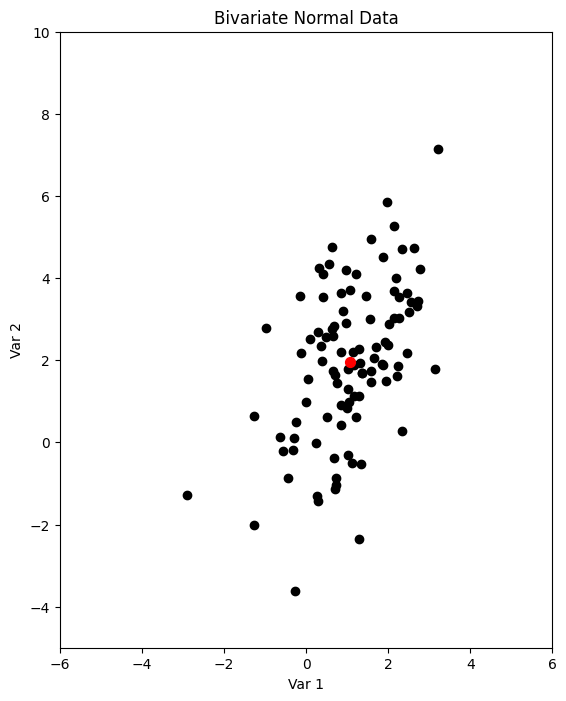

In [5]:
fig, ax = plt.subplots()

# Plot the data on a scatter plot
ax.scatter(X[:, 0], X[:, 1], color='black', marker='o')
# Add a red point with the sample mean
ax.scatter(mean_X[0], mean_X[1], color='red', s=50)

ax.set_xlabel('Var 1')
ax.set_ylabel('Var 2')
ax.set_xlim(-6, 6)
ax.set_ylim(-5, 10)
ax.set_aspect('equal', adjustable='box')    # set axes scaling
plt.title('Bivariate Normal Data')

Compute the variance along specific directions by projecting data along x- and y-axes (or simply considering only one of the two coordinates of the point in the scatter plot)

Variance along x-axis: 1.1063041224946633


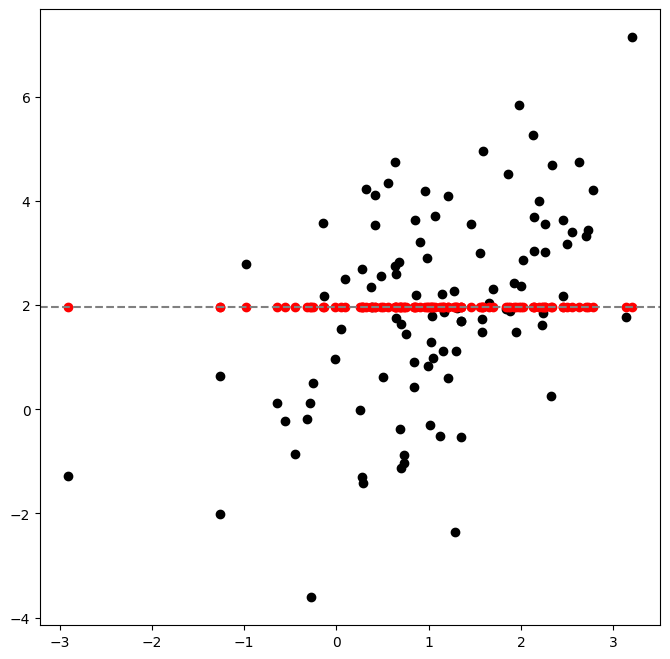

In [6]:
# Compute and plot variance of the projection of the data along the x-axis
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], color='black')
ax.axhline(mean_X[1], color='grey', linestyle='--')
# project all points on x-axis
ax.scatter(X[:, 0], np.full(n, mean_X[1]), color='red')
# ddof=1 computes the sample variance correctly (with n - 1 at the denominator)
var_x = np.var(X[:, 0], ddof=1)
print('Variance along x-axis:', var_x)

Variance along y-axis: 3.6623604597560124


Text(0.5, 1.0, 'Variance along Coordinate Axes')

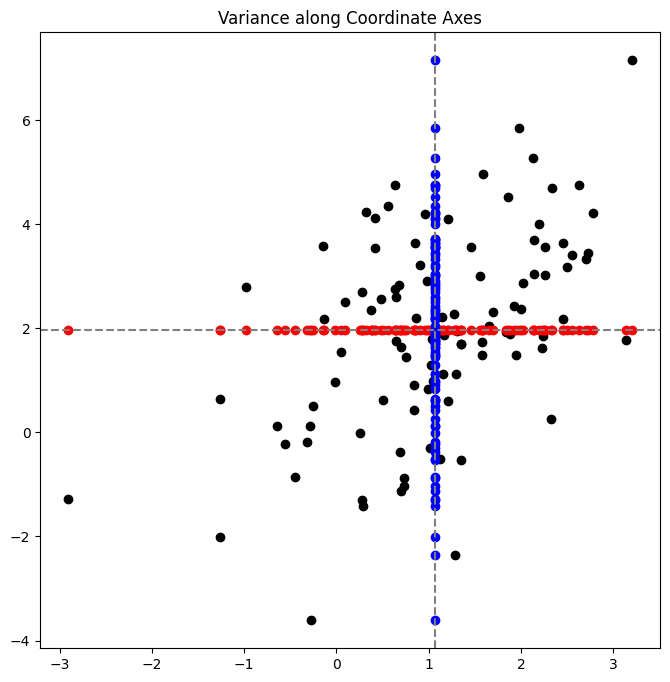

In [7]:
# Let's add the projection along the y-axis
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], color='black')
ax.axhline(mean_X[1], color='grey', linestyle='--')
ax.scatter(X[:, 0], np.full(n, mean_X[1]), color='red')

ax.axvline(mean_X[0], color='grey', linestyle='--')
ax.scatter(np.full(n, mean_X[0]), X[:, 1], color='blue')
var_y = np.var(X[:, 1], ddof=1)
print('Variance along y-axis:', var_y)
plt.title('Variance along Coordinate Axes')

Projection around a given projection (along $\theta = \pi/6$)

Variance along direction (pi/6): 2.6343768188470174


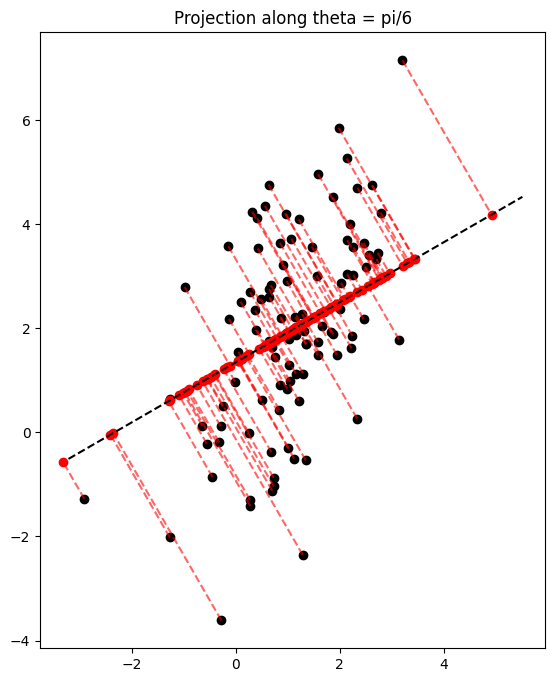

In [8]:
theta = np.pi / 6
a = np.array([np.cos(theta), np.sin(theta)])

proj30 = (X - mean_X) @ a  # Matrix multiplication for projection

fig, ax = plt.subplots()

# Plot original points
ax.scatter(X[:, 0], X[:, 1], color='black')

# Plot the projection line
x_line = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1]+2, 100)
y_line = mean_X[1] - np.tan(theta)*mean_X[0] + np.tan(theta)*x_line
ax.plot(x_line, y_line, linestyle='--', color='black')

# projected points
X_proj = np.column_stack([
    mean_X[0] + np.cos(theta) * proj30,
    mean_X[1] + np.sin(theta) * proj30
])

ax.scatter(X_proj[:, 0], X_proj[:, 1], color='red')

# Connections from original points to projections
for i in range(len(X)):
    ax.plot(
        [X[i, 0], X_proj[i, 0]],
        [X[i, 1], X_proj[i, 1]],
        linestyle='--',
        color='red',
        alpha=0.6
    )

ax.set_aspect('equal')

var_proj30 = np.var(proj30, ddof=1)
print('Variance along direction (pi/6):', var_proj30)

plt.title('Projection along theta = pi/6')
plt.show()

Compute variance along all directions, find min and max variance

In [9]:
thetas = np.linspace(0, np.pi, 181)
variances = []
for t in thetas:
    a_t = np.array([np.cos(t), np.sin(t)])
    v = np.var(X @ a_t, ddof=1)
    variances.append(v)

variances = np.array(variances)
max_var = variances.max()
max_theta = thetas[variances.argmax()]
min_var = variances.min()
min_theta = thetas[variances.argmin()]

Convert the value of the angle to degree first

In [10]:
max_theta / np.pi * 180

np.float64(71.0)

In [11]:
min_theta / np.pi * 180

np.float64(161.0)

In [12]:
max_var

np.float64(4.023468121296431)

In [13]:
min_var

np.float64(0.7451964609542457)

Plot variance along all directions, highlighting directions with min and max variance (that are orthogonal one with each other)

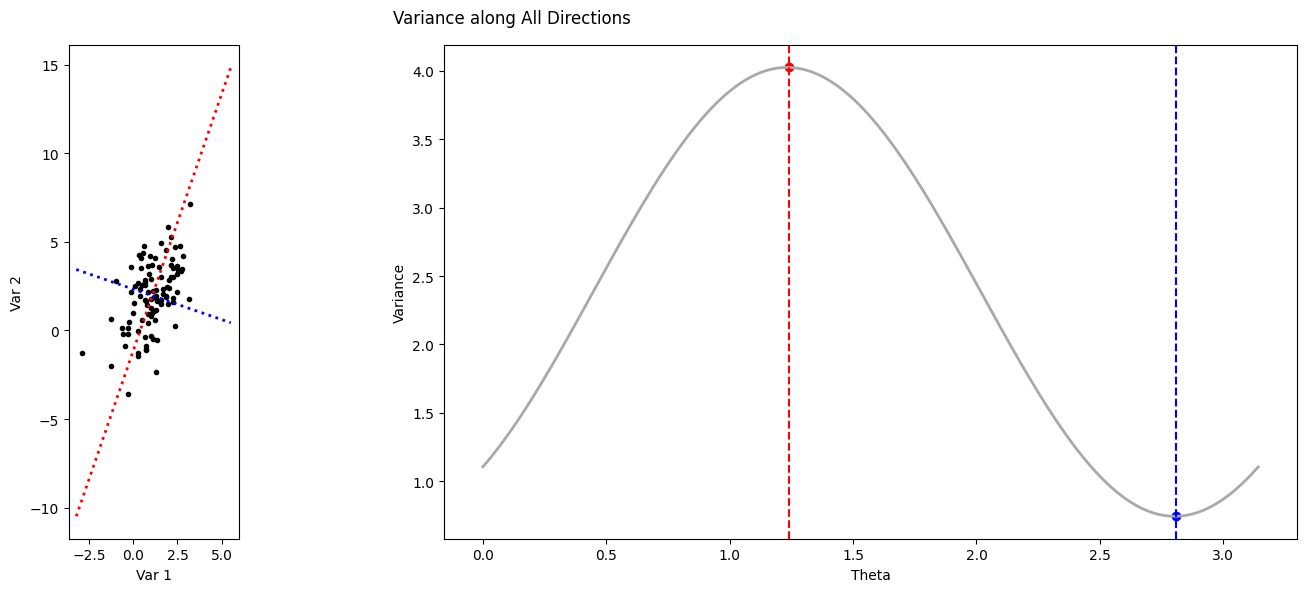

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].scatter(X[:, 0], X[:, 1], color='black', marker='.')
axs[0].plot(x_line, mean_X[1] - np.tan(max_theta)*mean_X[0] + np.tan(max_theta)*x_line,
            linestyle=':', color='red', linewidth=2)
axs[0].plot(x_line, mean_X[1] - np.tan(min_theta)*mean_X[0] + np.tan(min_theta)*x_line,
            linestyle=':', color='blue', linewidth=2)
axs[0].set_xlabel('Var 1')
axs[0].set_ylabel('Var 2')
axs[0].set_aspect('equal')

axs[1].plot(thetas, variances, color='darkgrey', linewidth=2)
axs[1].scatter([max_theta], [max_var], color='red')
axs[1].scatter([min_theta], [min_var], color='blue')
axs[1].axvline(max_theta, color='red', linestyle='--')
axs[1].axvline(min_theta, color='blue', linestyle='--')
axs[1].set_xlabel('Theta')
axs[1].set_ylabel('Variance')
plt.suptitle('Variance along All Directions')
plt.tight_layout()
plt.show()

The proposed process could be theoretically used to perform PCA by simply expliciting all the possible directions (chosen from a discrete set), finding the direction of maximum variability by computing and comparing the variances for these directions and then determine the orthogonal direction. Moreover, it is a way to convince ourselves that computing the eigenvalues and eigenvectors of the covariance matrix is the same as finding the direction of maximal variability in the dataset

## Comparison with the theory

PCA is obtained by computing the covariance matrix, its eigenvectors and eigenvalues

In [15]:
M = mean_X  # sample mean
S = np.cov(X, rowvar=False)  # Features are represented on columns
eigvals, eigvecs = np.linalg.eig(S)
order = eigvals.argsort()[::-1]  # sort eigvals in descending order
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)
print("Empirical max variance:", max_var)
print("Empirical min variance:", min_var)

max_a = np.array([np.cos(max_theta), np.sin(max_theta)])
min_a = np.array([np.cos(min_theta), np.sin(min_theta)])
print(f"Empirical max direction: {max_a} (theta={max_theta})")
print(f"Empirical min direction: {min_a} (theta={min_theta})")

Eigenvalues: [4.02361759 0.74504699]
Eigenvectors (columns):
 [[-0.33194486 -0.94329879]
 [-0.94329879  0.33194486]]
Empirical max variance: 4.023468121296431
Empirical min variance: 0.7451964609542457
Empirical max direction: [0.32556815 0.94551858] (theta=1.239183768915974)
Empirical min direction: [-0.94551858  0.32556815] (theta=2.8099800957108707)


The empirical result and the computed result differ by a sign that is natural as eigenvectors are defined up to a constant; practically, we are referring to the same direction of variability

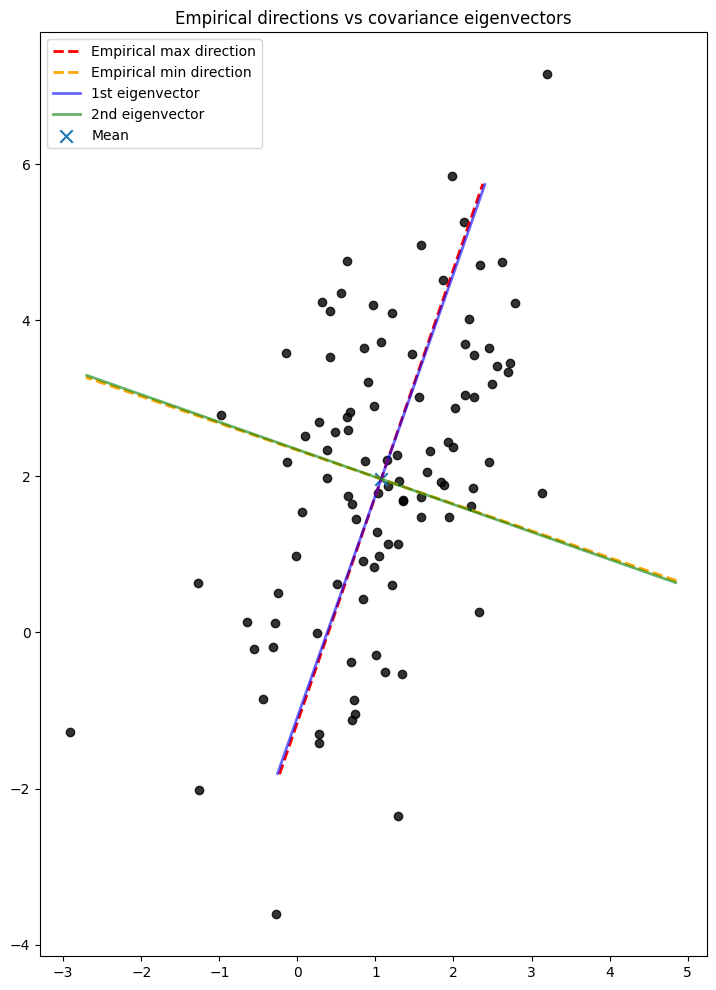

In [16]:
# Length for drawing lines
L = 4

fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(X[:, 0], X[:, 1], color="black", alpha=0.8)

# Empirical max direction
ax.plot(
    [M[0] - L * max_a[0], M[0] + L * max_a[0]],
    [M[1] - L * max_a[1], M[1] + L * max_a[1]],
    '--', lw=2, label='Empirical max direction', color='red'
)

# Empirical min direction
ax.plot(
    [M[0] - L * min_a[0], M[0] + L * min_a[0]],
    [M[1] - L * min_a[1], M[1] + L * min_a[1]],
    '--', lw=2, label='Empirical min direction', color='orange'
)

# Eigenvectors
v1 = eigvecs[:, 0].copy()
v2 = eigvecs[:, 1].copy()

# Align signs for easier visual comparison
if np.dot(v1, max_a) < 0:
    v1 = -v1
if np.dot(v2, min_a) < 0:
    v2 = -v2

# First eigenvector
ax.plot(
    [M[0] - L * v1[0], M[0] + L * v1[0]],
    [M[1] - L * v1[1], M[1] + L * v1[1]],
    '-', lw=2, label='1st eigenvector', alpha=0.6, color='blue'
)

# Second eigenvector
ax.plot(
    [M[0] - L * v2[0], M[0] + L * v2[0]],
    [M[1] - L * v2[1], M[1] + L * v2[1]],
    '-', lw=2, label='2nd eigenvector', alpha=0.6, color='green'
)

ax.scatter(M[0], M[1], s=80, marker='x', label='Mean')

ax.set_title("Empirical directions vs covariance eigenvectors")
ax.set_aspect("equal")
ax.legend()
plt.show()

# PCA Example - Tourists Dataset

## Load and visualize dataset

The dataset `tourists.txt` collects the data on the flow of Italian tourism
from outside Lombardy to Milan for the year 2015. Each statistical unit
corresponds to a Region of origin and a month of observation. For each unit,
the tourist flow is quantified through the number of nights spent by clients
in: '5 stars hotels', '4 stars hotels', '3 stars hotels', '2 stars hotels',
'1 star hotels', 'residences', 'B&B' and 'rented flats'.

In [17]:
from google.colab import drive  # pyright: ignore[reportMissingImports]

In [18]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# change the current working directory
os.chdir('/content/drive/MyDrive/Applied Statistics/Datasets')

In the `csv` file, the data are separated by a space

In [20]:
# Read the tourists dataset
tourists = pd.read_csv('tourists.txt', sep=' ')
print(tourists.head())

  Month Region.of.origin  Hotel.5stars  Hotel.4stars  Hotel.3stars  \
1   Jan         PIEMONTE           255          5733          3878   
2   Feb         PIEMONTE           277          6613          3816   
3   Mar         PIEMONTE           272          7278          4518   
4   Apr         PIEMONTE           181          5311          3550   
5   May         PIEMONTE           301          5885          3231   

   Hotel.2stars  Hotel.1star  Residences  Bed.Breakfast  Rented.flats  
1           351          504        1489             41           551  
2           352          380        1617             31           415  
3           523          475        1949             42           520  
4           383          330        1853             42           542  
5           396          421        2050             85           561  


`iloc()` is used to select rows and columns from a dataframe by using their
integer positions (starting from 0)

In [21]:
tourists_data = tourists.iloc[:, 2:]
tourists_label = tourists.iloc[:, :2]
n_tour, p_tour = tourists_data.shape
print('Tourists dataset shape:', tourists_data.shape)

Tourists dataset shape: (240, 8)


Boxplot of original data, without relying on the boxplots created by Seaborn

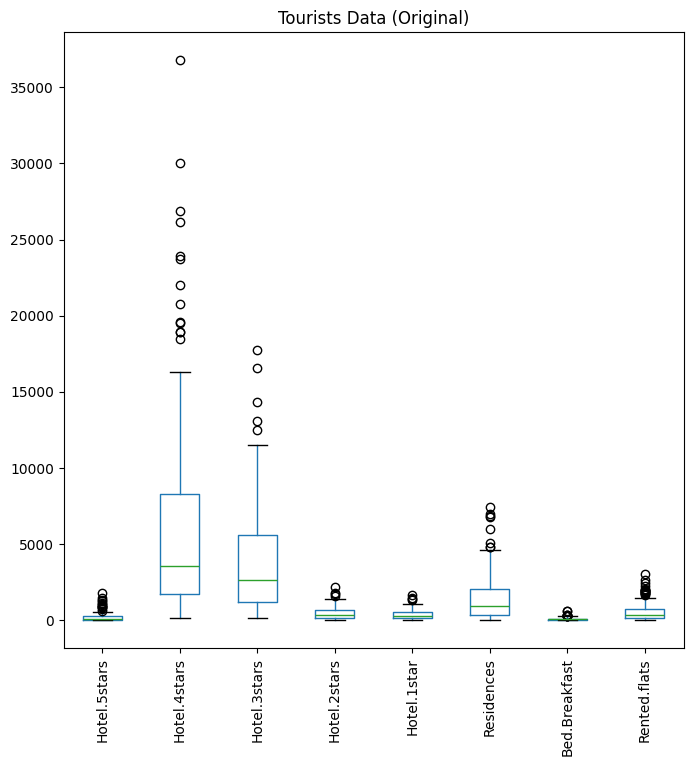

In [22]:
plt.figure()
tourists_data.boxplot(rot=90, grid=False)
plt.title('Tourists Data (Original)')
plt.show()

PCA is not about the mean, it is about the variability, so we need to center the data around the mean. To do this, we must remove the mean from the data, so that data on which PCA is computed has mean zero. The resulting boxplot is the same one as before but only shifted by a certain amount

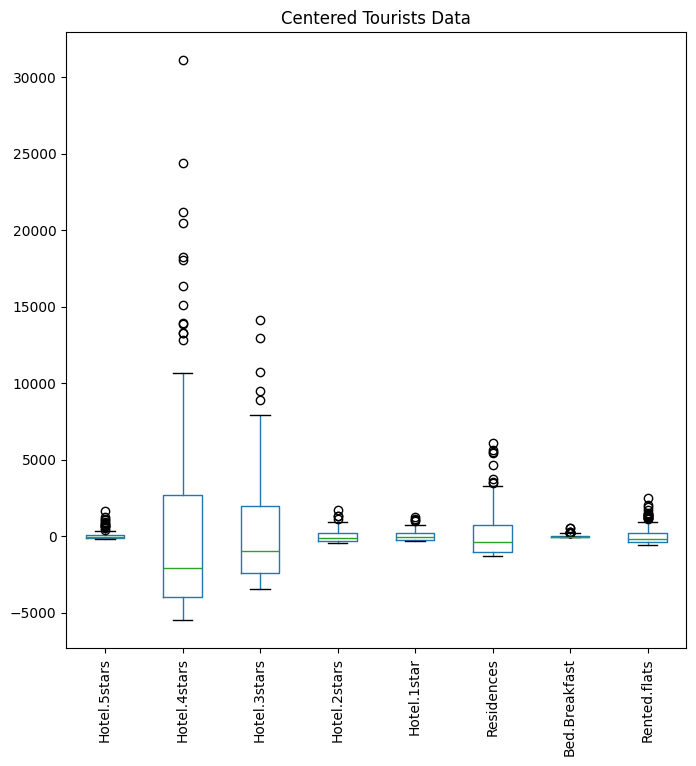

In [23]:
tourists_centered = tourists_data - tourists_data.mean()

ax = tourists_centered.boxplot(rot=90, grid=False)
plt.title('Centered Tourists Data')
plt.show()

## PCA on original data

This is the fastest method to apply PCA in Python by avoiding all the mathematical steps behind it and simply calling `PCA` method and applying `fit_transform` on the PCA object returned by the first method. The first PCA component is capturing 98% of variability, whereas the variability captured by successive components becomes negligible.

In [24]:
pca_tourists = PCA()
tourists_scores = pca_tourists.fit_transform(tourists_data)
print('Tourists PCA explained variance ratio:\n',
      pca_tourists.explained_variance_ratio_)

Tourists PCA explained variance ratio:
 [9.80435551e-01 1.54348931e-02 3.01060627e-03 5.99554411e-04
 3.13904868e-04 9.33619028e-05 8.57873032e-05 2.63408204e-05]


The cumulative variance will be 1 if we keep all the PCA components

In [25]:
pc_sd = np.sqrt(pca_tourists.explained_variance_)
print("Standard deviation of the components:")
print(pc_sd)

# Cumulative proportion of explained variance
cumulative_explained_variance = np.cumsum(
    pca_tourists.explained_variance_ratio_)
print("Cumulative proportion of explained variance:")
print(cumulative_explained_variance)

Standard deviation of the components:
[6586.75180678  826.44429714  364.99654582  162.88311834  117.85847007
   64.27567128   61.61313141   34.14101456]
Cumulative proportion of explained variance:
[0.98043555 0.99587044 0.99888105 0.99948061 0.99979451 0.99988787
 0.99997366 1.        ]


In PCA, each component is given by a linear combination of the original variables, which coefficients are called loadings.

In [26]:
load_tour = pca_tourists.components_.T
load_tour

array([[ 0.036988  , -0.06875905,  0.03032049, -0.01538322, -0.09843182,
         0.1792697 ,  0.87877522, -0.42270057],
       [ 0.86250762, -0.48404327, -0.12963676,  0.00331453,  0.03025384,
         0.0104852 , -0.06070552,  0.01598857],
       [ 0.45374825,  0.83652698, -0.17078613, -0.151654  , -0.20265148,
        -0.01267825,  0.03057386,  0.00227378],
       [ 0.0525281 ,  0.14868959, -0.1461287 ,  0.15710032,  0.79181454,
        -0.5148528 ,  0.15814922, -0.10974173],
       [ 0.03921975,  0.14477781, -0.04127983,  0.2494434 ,  0.45701223,
         0.81423507, -0.16034057, -0.12659831],
       [ 0.19594019,  0.10300007,  0.95393089, -0.12569757,  0.15539773,
        -0.02558117, -0.00302853,  0.0200594 ],
       [ 0.01153809,  0.01380745, -0.02285702,  0.08655516,  0.10166414,
         0.13233387,  0.41520552,  0.88961706],
       [ 0.07747214,  0.08560395,  0.13979581,  0.93089164, -0.27930944,
        -0.14619468, -0.00302077, -0.03423665]])

/tmp/ipykernel_543/3236212354.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tourists_data.columns, rotation=90)
/tmp/ipykernel_543/3236212354.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tourists_data.columns, rotation=90)
/tmp/ipykernel_543/3236212354.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tourists_data.columns, rotation=90)


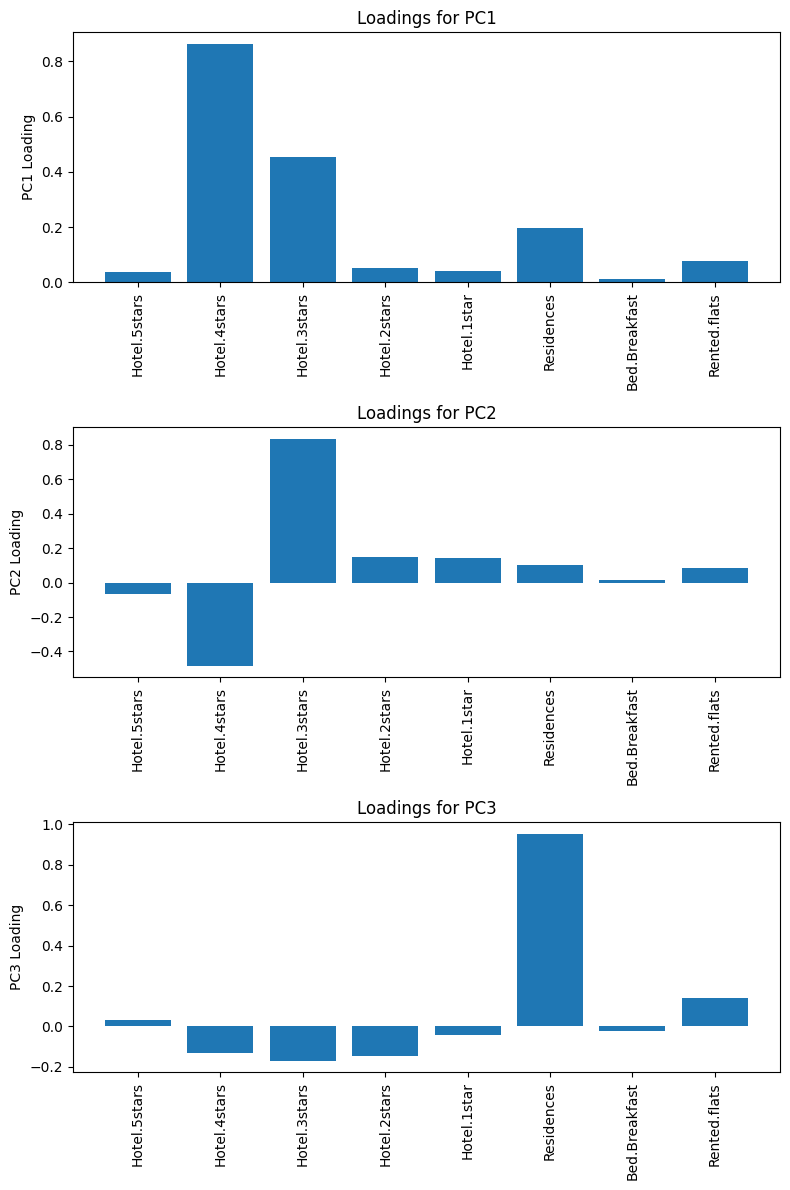

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

for i, ax in enumerate(axes):
    ax.bar(tourists_data.columns, load_tour[:, i])
    ax.set_xticklabels(tourists_data.columns, rotation=90)
    ax.set_ylabel(f"PC{i+1} Loading")
    ax.set_title(f"Loadings for PC{i+1}")

plt.tight_layout()
plt.show()

Interpretation of the loadings, neglecting the sign:

- PC1: weighted average of the number of nights in 3,4 stars hotel and residences; it highlights a flow of tourism that goes into a specific group of accomodations, typically associated with a medium-high cost

- PC2: it highlights that the direction described by PCA2 constrants 3 star hotels and 4 star hotels. There are people going to 3-star hotel only and viceversa

- PC3: residences

The loadings reflect the previous observation: the first 3 PCs are
driven by the variables displaying the highest variability

The interpretability of the components is one key feature of PCA

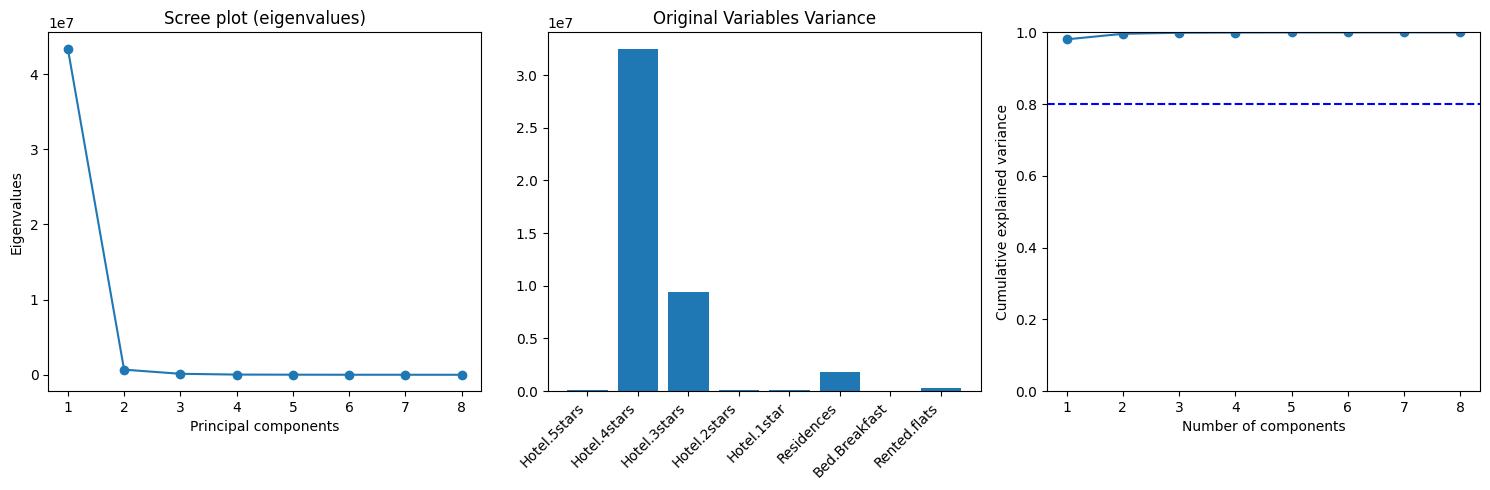

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(np.arange(1, p_tour+1),
            pca_tourists.explained_variance_, marker='o')
axs[0].set_title('Scree plot (eigenvalues)')
axs[0].set_xlabel('Principal components')
axs[0].set_ylabel('Eigenvalues')

orig_variances = tourists_data.var(ddof=1)
axs[1].bar(tourists_data.columns, orig_variances)
axs[1].tick_params(axis='x', rotation=45)
plt.setp(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[1].set_title('Original Variables Variance')
cum_explained = np.cumsum(pca_tourists.explained_variance_ratio_)

axs[2].plot(np.arange(1, p_tour+1), cum_explained, marker='o')
axs[2].axhline(0.8, color='blue', linestyle='--')
axs[2].set_xlabel('Number of components')
axs[2].set_ylabel('Cumulative explained variance')
axs[2].set_ylim(0, 1)
plt.tight_layout()
plt.show()

In PCA applications for visualizing data, two/three PCs are kept, whereas in PCA for dimensionality reduction, we retain a number of components so that a certain variability (e.g. 80%) is captured. In other scenario, we cut PCs when an elbow shows up in the scree plot

## PCA on standardized data

Data standardization is always recommended before doing PCA

$$
Z = \frac{X - \mu}{\sigma}
$$

The fastest way to achieve this is using `StandardScaler` object from Scipy.

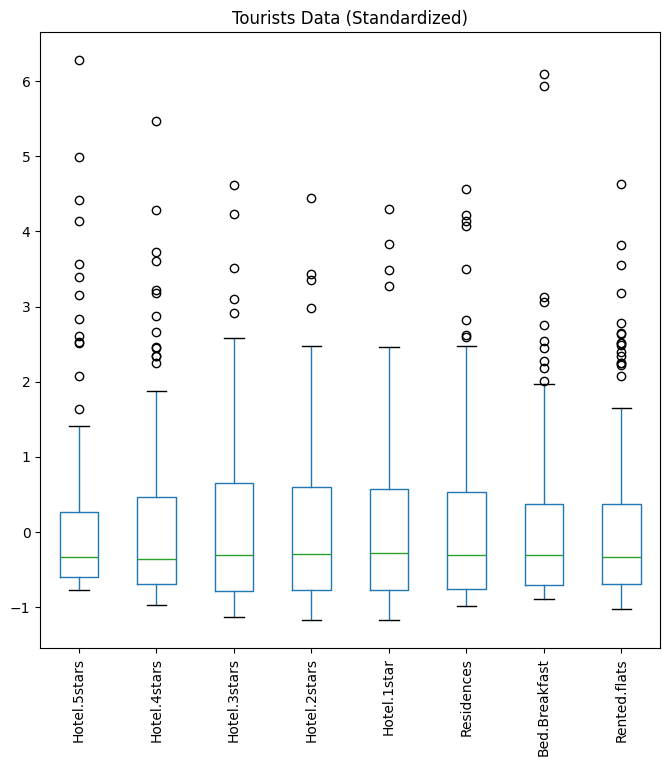

In [29]:
scaler = StandardScaler()
tourists_std = scaler.fit_transform(tourists_data)
tourists_std_df = pd.DataFrame(tourists_std, columns=tourists_data.columns)
plt.figure()
tourists_std_df.boxplot(rot=90, grid=False)
plt.title('Tourists Data (Standardized)')
plt.show()

PCA on standardized data

In [30]:
pca_tourists_std = PCA()
tourists_scores_std = pca_tourists_std.fit_transform(tourists_std_df)
print('Standardized Tourists PCA explained variance ratio:\n',
      pca_tourists_std.explained_variance_ratio_)
load_tour_std = pca_tourists_std.components_.T

Standardized Tourists PCA explained variance ratio:
 [0.89611484 0.05050789 0.02706031 0.01157808 0.00621128 0.00457926
 0.00256891 0.00137943]


In [31]:
pc_sd = np.sqrt(pca_tourists_std.explained_variance_)
print("Standard deviation of the components:")
print(pc_sd)

cumulative_explained_variance = np.cumsum(
    pca_tourists_std.explained_variance_ratio_)
print("Cumulative proportion of explained variance:")
print(cumulative_explained_variance)

Standard deviation of the components:
[2.68307923 0.63698806 0.46624916 0.30497896 0.22337895 0.19180022
 0.14365681 0.10526936]
Cumulative proportion of explained variance:
[0.89611484 0.94662273 0.97368304 0.98526112 0.9914724  0.99605166
 0.99862057 1.        ]


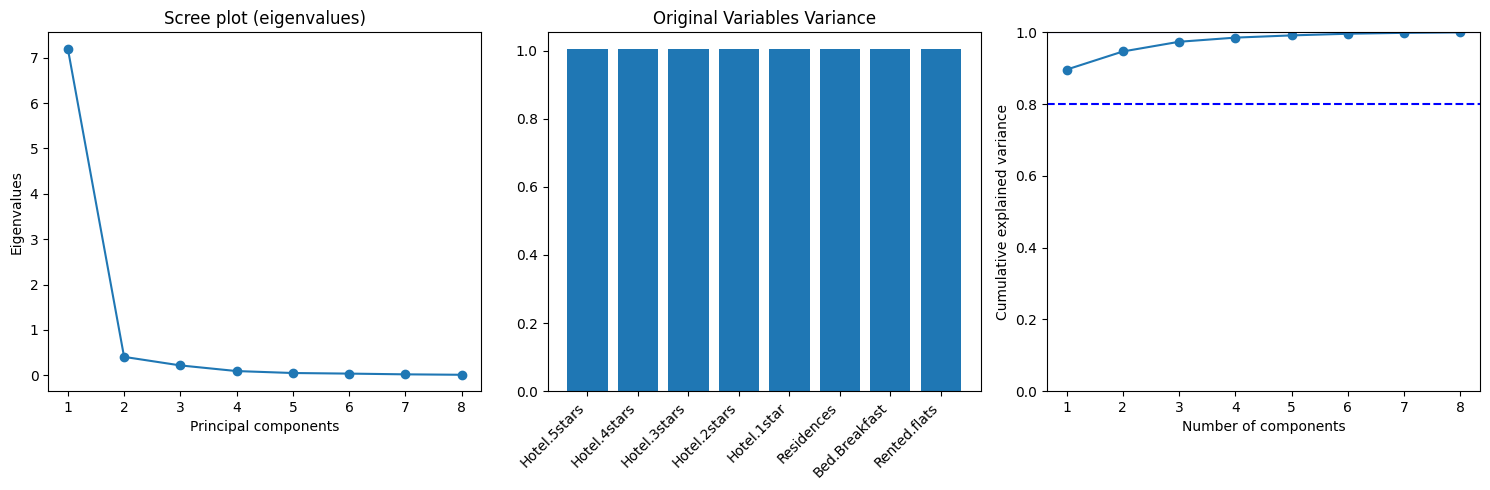

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(np.arange(1, p_tour+1),
            pca_tourists_std.explained_variance_, marker='o')
axs[0].set_title('Scree plot (eigenvalues)')
axs[0].set_xlabel('Principal components')
axs[0].set_ylabel('Eigenvalues')

orig_variances = tourists_std_df.var(ddof=1)
axs[1].bar(tourists_data.columns, orig_variances)
axs[1].tick_params(axis='x', rotation=45)
plt.setp(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[1].set_title('Original Variables Variance')

cum_explained = np.cumsum(pca_tourists_std.explained_variance_ratio_)
axs[2].plot(np.arange(1, p_tour+1), cum_explained, marker='o')
axs[2].axhline(1, color='blue')
axs[2].axhline(0.8, color='blue', linestyle='--')
axs[2].set_xlabel('Number of components')
axs[2].set_ylabel('Cumulative explained variance')
axs[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

If we wanted to perform dimensionality reduction, we could keep 1 or 2 PCs as there is a significant variability that can be captured between them

Loadings and their barplots for the first three PCs

In [33]:
load_tour_std = pca_tourists_std.components_.T
load_tour_std

array([[ 0.34094343,  0.59123382,  0.19309851, -0.26881534, -0.14749888,
         0.40169545, -0.32438137, -0.36920591],
       [ 0.36303235,  0.30520188, -0.0638927 , -0.27124653, -0.16271971,
        -0.00646527,  0.34510892,  0.74282077],
       [ 0.36824629, -0.0754591 , -0.20740553, -0.15913374,  0.07951614,
        -0.10460492,  0.69912569, -0.53321503],
       [ 0.3519069 , -0.42808893, -0.07764867, -0.50223959, -0.22697655,
        -0.43716996, -0.43661624, -0.03684846],
       [ 0.34676276, -0.52252462, -0.17281238,  0.07582116,  0.15164369,
         0.72368312, -0.07946065,  0.13447521],
       [ 0.35803476,  0.25373557, -0.30791029,  0.23674428,  0.70801281,
        -0.27644559, -0.27417451,  0.06080133],
       [ 0.33792625, -0.17132443,  0.86887665,  0.1935478 ,  0.18520528,
        -0.13472994,  0.09804763,  0.04449633],
       [ 0.36040788,  0.03967862, -0.17310351,  0.69089654, -0.57909089,
        -0.13508378, -0.07188258, -0.04967821]])

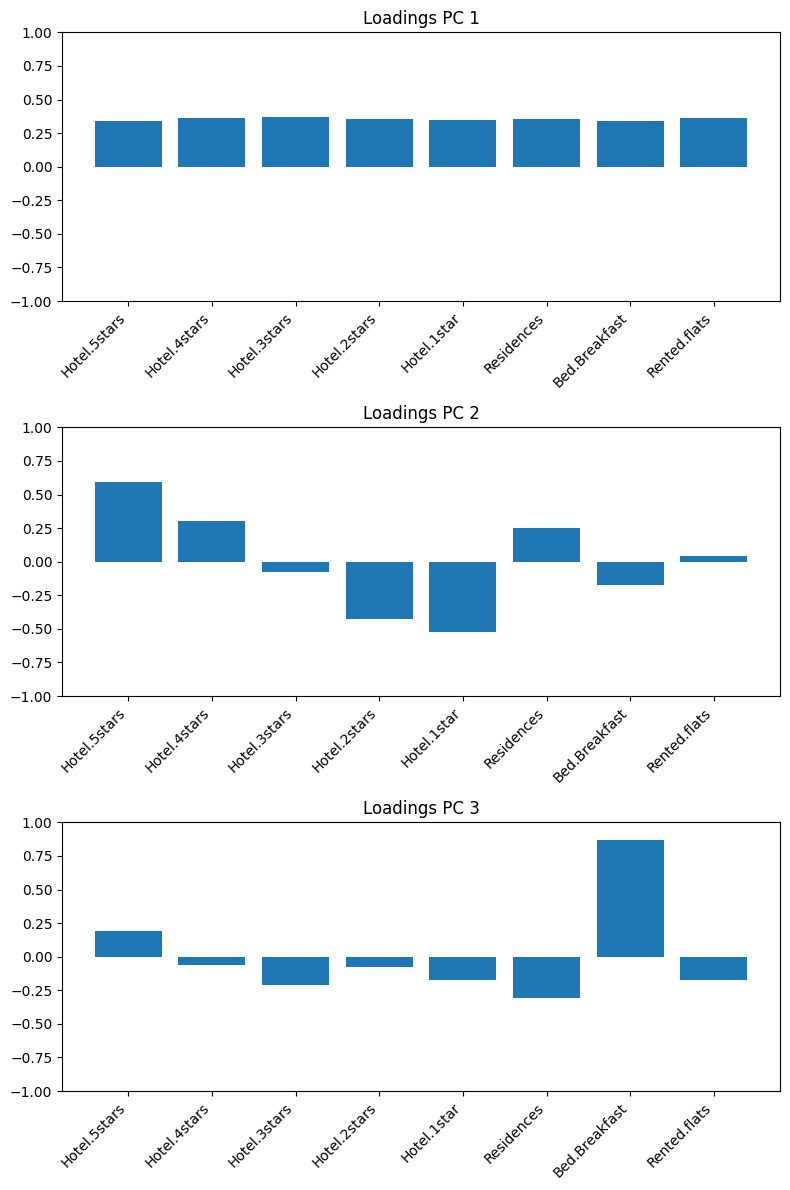

In [34]:
fig, axs = plt.subplots(3, 1, figsize=(8, 12))
for i in range(3):
    axs[i].bar(tourists_std_df.columns, load_tour_std[:, i])
    axs[i].set_ylim([-1, 1])
    axs[i].set_title(f'Loadings PC {i+1}')
    axs[i].tick_params(axis='x', rotation=45)
    plt.setp(axs[i].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In this case, the first PC represents an average of the number of nights spent in all the types of hotels and residences, taken with very similar weights; it highlights a general flow of tourists in the region on a certain period of time (low or high)
The second PC contrasts the more expensive solutions (4,5 stars hotels and residences) against the cheap solutions (1,2 stars hotels and B&B); having a high score for PC2 means there is a significant flow for expensive solutions and a lower flow for cheaper solutions, while a low score can be interpreted the opposite. 
The third PC focuses on B&B

## Interpretations with categorical variables

Project the data applying PCA in the standardized dataset

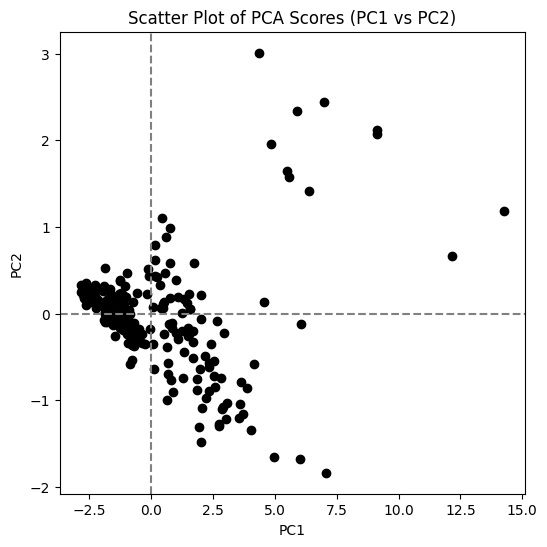

In [35]:
scores_tourists = pca_tourists_std.transform(tourists_std_df)
n = scores_tourists.shape[0]

# Scatter plot of the scores for the first two PCs
plt.figure(figsize=(6, 6))
plt.scatter(scores_tourists[:, 0],
            scores_tourists[:, 1], color='black', marker='o')
plt.axhline(0, linestyle='--', color='grey')
plt.axvline(0, linestyle='--', color='grey')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter Plot of PCA Scores (PC1 vs PC2)")
plt.show()

Analysis by month (for discovering patterns in data)

In [36]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sept", "Oct", "Nov", "Dec"]

# Convert the first column to an ordered categorical variable
tourists_label['Month'] = pd.Categorical(tourists_label.iloc[:, 0],
                                         categories=months,
                                         ordered=True)

# Define a cyclic palette for the 12 months
palette = ["#2D1857", "#4D2C8C", "#6C47C7", "#8B63FF", "#7A8CDD", "#68B5C5",
           "#5ECABA", "#46AF89", "#108963", "#047138", "#025A26", "#013814"]

# Map each month to a color
month_to_color = {m: c for m, c in zip(months, palette)}
col_lab1 = tourists_label['Month'].map(month_to_color)

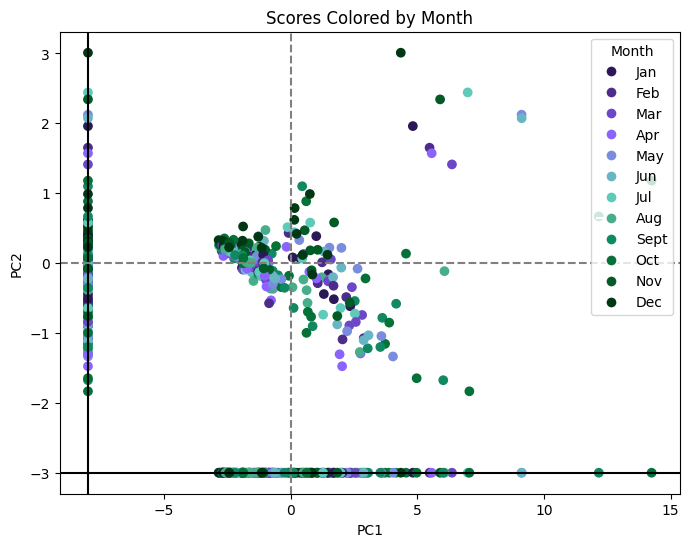

In [37]:
# Scatter plot of scores colored by month
plt.figure(figsize=(8, 6))
plt.scatter(scores_tourists[:, 0],
            scores_tourists[:, 1], c=col_lab1, marker='o')
plt.axhline(-3, color='black')
plt.axvline(-8, color='black')
# Additional points along the margins
plt.scatter(scores_tourists[:, 0], np.full(n, -3), c=col_lab1, marker='o')
plt.scatter(np.full(n, -8), scores_tourists[:, 1], c=col_lab1, marker='o')
plt.axhline(0, linestyle='--', color='grey')
plt.axvline(0, linestyle='--', color='grey')
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Scores Colored by Month")

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=month_to_color[m],
                             markersize=8, label=m) for m in months]
plt.legend(handles=legend_handles, title="Month", loc='upper right')
plt.show()

Analysis for month of Expo (May to Oct)

/tmp/ipykernel_543/966687091.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Expo', y='PC2', data=scores_df, ax=ax_box_y,
/tmp/ipykernel_543/966687091.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PC1', y='Expo', data=scores_df, ax=ax_box_x,


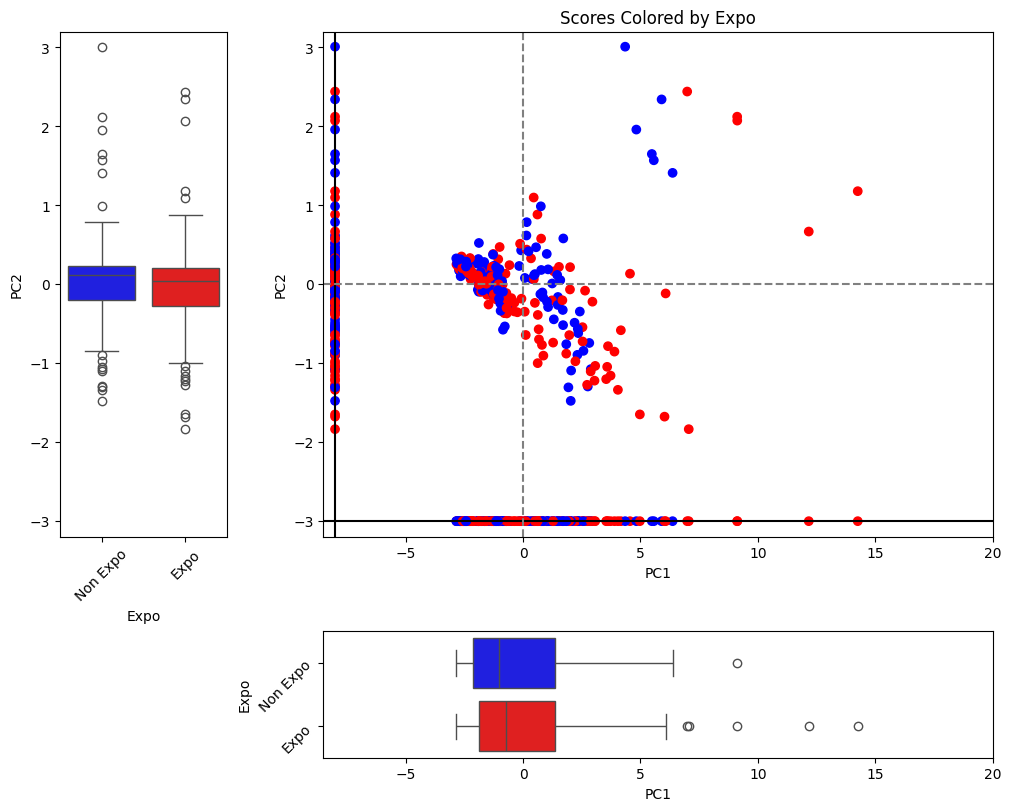

In [38]:
import matplotlib.gridspec as gridspec
expo_months = ["May", "Jun", "Jul", "Aug", "Sept", "Oct"]

# Create a new column 'Expo' that is 'Expo' if the month is in expo_months, otherwise 'Non Expo'
tourists_label['Expo'] = tourists_label['Month'].apply(
    lambda m: 'Expo' if m in expo_months else 'Non Expo')

# Define colors for Expo groups.
col_expo = tourists_label['Expo'].map({'Expo': 'red', 'Non Expo': 'blue'})

# Create a layout with a scatter plot and two boxplots.
fig = plt.figure(constrained_layout=True, figsize=(10, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 4], height_ratios=[4, 1])

ax_scatter = fig.add_subplot(gs[0, 1])
ax_box_y = fig.add_subplot(gs[0, 0], sharey=ax_scatter)
ax_box_x = fig.add_subplot(gs[1, 1], sharex=ax_scatter)

# Scatter plot with expo colors
ax_scatter.scatter(scores_tourists[:, 0],
                   scores_tourists[:, 1], c=col_expo, marker='o')
ax_scatter.set_xlim(-8.5, 20)
ax_scatter.set_ylim(-3.2, 3.2)
ax_scatter.axhline(-3, color='black')
ax_scatter.axvline(-8, color='black')
ax_scatter.scatter(scores_tourists[:, 0], np.full(
    n, -3), c=col_expo, marker='o')
ax_scatter.scatter(
    np.full(n, -8), scores_tourists[:, 1], c=col_expo, marker='o')
ax_scatter.axhline(0, linestyle='--', color='grey')
ax_scatter.axvline(0, linestyle='--', color='grey')
ax_scatter.set_xlabel("PC1")
ax_scatter.set_ylabel("PC2")
ax_scatter.set_title("Scores Colored by Expo")

# Prepare a DataFrame for boxplots
scores_df = pd.DataFrame(scores_tourists[:, :2], columns=["PC1", "PC2"])
scores_df['Expo'] = tourists_label['Expo']

# Boxplot for PC2 grouped by Expo (vertical boxplot)
sns.boxplot(x='Expo', y='PC2', data=scores_df, ax=ax_box_y,
            palette={'Expo': 'red', 'Non Expo': 'blue'})
ax_box_y.set_ylim(-3.2, 3.2)
ax_box_y.tick_params(axis='x', rotation=45)

# Boxplot for PC1 grouped by Expo (horizontal boxplot)
sns.boxplot(x='PC1', y='Expo', data=scores_df, ax=ax_box_x,
            palette={'Expo': 'red', 'Non Expo': 'blue'}, orient='h')
ax_box_x.set_xlim(-8.5, 20)
ax_box_x.tick_params(axis='y', rotation=45)

plt.show()

Scores Colored by Region of Origin  
Some regions have a high flow of tourists choosing high-level accomodations, whereas tourists from other regions (e.g. Campania) tend to prefer low-level accomodations

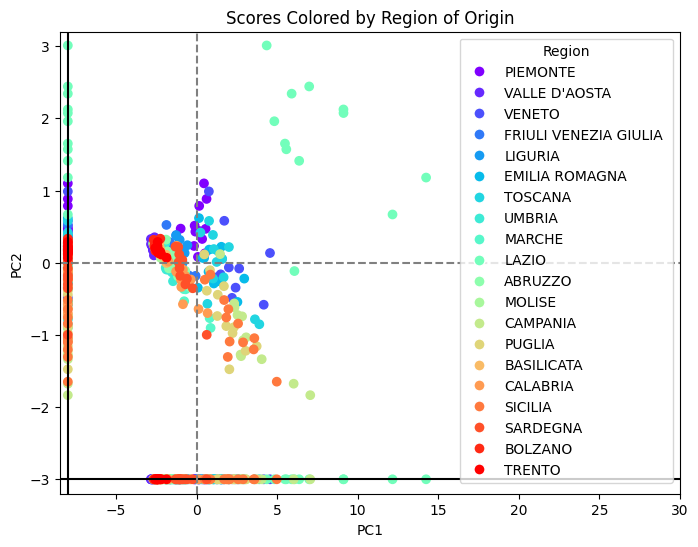

In [39]:
regions = tourists_label['Region.of.origin'].unique()
# Create a color mapping using a rainbow colormap
region_colors = {region: color for region, color in zip(
    regions, plt.cm.rainbow(np.linspace(0, 1, len(regions))))}
col_lab2 = tourists_label.iloc[:, 1].map(region_colors)

plt.figure(figsize=(8, 6))
plt.scatter(scores_tourists[:, 0],
            scores_tourists[:, 1], c=col_lab2, marker='o')
plt.xlim(-8.5, 30)
plt.ylim(-3.2, 3.2)
plt.axhline(-3, color='black')
plt.axvline(-8, color='black')
plt.scatter(scores_tourists[:, 0], np.full(n, -3), c=col_lab2, marker='o')
plt.scatter(np.full(n, -8), scores_tourists[:, 1], c=col_lab2, marker='o')
plt.axhline(0, linestyle='--', color='grey')
plt.axvline(0, linestyle='--', color='grey')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scores Colored by Region of Origin")
# Create legend for regions.
legend_handles_regions = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=region_colors[r],
                                     markersize=8, label=r) for r in regions]
plt.legend(handles=legend_handles_regions, title="Region", loc='upper right')
plt.show()

# t-SNE & UMAP - Genomic dataset

Genetic data collecting the amount of expression of genes inside a cell. The size of the dataset is "bad" as the number of records and the number of features is comparable (same order of magnitude)

## Load data

In [40]:
# Cells in rows, genes in columns
expression_data = pd.read_csv("expression.csv", index_col=0)
# Classes
meta_data = pd.read_csv("meta.csv", index_col=0)

In [41]:
expression_data

,TNFRSF4,CPSF3L,ATAD3C,C1orf86,RER1,TNFRSF25,TNFRSF9,CTNNBIP1,SRM,UBIAD1,...,DSCR3,BRWD1,BACE2,SIK1,C21orf33,ICOSLG,SUMO3,SLC19A1,S100B,PRMT2
0,,,,,,,,,,,,,,,,,,,,,
AAACATACAACCAC-1,-0.171470,-0.280812,-0.046677,-0.475169,-0.544024,4.928496,-0.038028,-0.280573,-0.341788,-0.195361,...,-0.226570,-0.236269,-0.102943,-0.222116,-0.312401,-0.121678,-0.521229,-0.098269,-0.209095,-0.531203
AAACATTGAGCTAC-1,-0.214582,-0.372653,-0.054804,-0.683391,0.633951,-0.334837,-0.045589,-0.498264,-0.541914,-0.209017,...,-0.317531,2.568868,0.007155,-0.445372,1.629285,-0.058662,-0.857163,-0.266844,-0.313146,-0.596654
AAACATTGATCAGC-1,-0.376888,-0.295085,-0.057527,-0.520972,1.332648,-0.309362,-0.103108,-0.272526,-0.500799,-0.220228,...,-0.302938,-0.239801,-0.071774,-0.297857,-0.410920,-0.070431,-0.590720,-0.158656,-0.170876,1.379000
AAACCGTGCTTCCG-1,-0.285241,-0.281735,-0.052227,-0.484929,1.572680,-0.271825,-0.074552,-0.258875,-0.416752,-0.208471,...,-0.262978,-0.231807,-0.093818,-0.247770,2.552079,-0.097402,1.631684,-0.119462,-0.179120,-0.505669
AAACCGTGTATGCG-1,-0.256484,-0.220394,-0.046800,-0.345859,-0.333409,-0.208122,-0.069514,5.806440,-0.283112,-0.199355,...,-0.202237,-0.176765,-0.167350,-0.098665,-0.275836,-0.139482,-0.310095,-0.006877,-0.109614,-0.461946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,-0.290368,2.638308,-0.054510,-0.554384,-0.666646,-0.301333,-0.074079,-0.334131,-0.478076,-0.211993,...,2.865904,-0.259985,-0.057421,-0.320982,-0.396917,-0.078147,1.232167,-0.174593,-0.216714,-0.529870
TTTCTACTGAGGCA-1,-0.386344,2.652699,-0.058686,-0.545443,1.201866,-0.321670,-0.105418,-0.296857,1.803535,-0.222323,...,-0.314890,-0.249159,-0.058679,-0.324692,-0.427120,-0.062188,-0.630102,-0.178990,-0.181736,-0.502022
TTTCTACTTCCTCG-1,-0.207090,-0.250464,-0.046397,-0.409737,2.193954,-0.221747,-0.051566,-0.198130,-0.307756,-0.196557,...,-0.212130,-0.206711,10.000000,-0.158643,3.308513,-0.132098,2.264172,-0.051144,-0.161064,2.041497


In [42]:
meta_data

,n_genes,percent_mito,n_counts,cell_type
0,,,,
AAACATACAACCAC-1,781,0.030178,2419,CD4 T
AAACATTGAGCTAC-1,1352,0.037936,4903,B CELLS
AAACATTGATCAGC-1,1131,0.008897,3147,CD4 T
AAACCGTGCTTCCG-1,960,0.017431,2639,CD14+ Monocytes
AAACCGTGTATGCG-1,522,0.012245,980,NK CELLS
...,...,...,...,...
TTTCGAACTCTCAT-1,1155,0.021104,3459,CD14+ Monocytes
TTTCTACTGAGGCA-1,1227,0.009294,3443,B CELLS
TTTCTACTTCCTCG-1,622,0.021971,1684,B CELLS


## PCA

Let's run a PCA first retaining only two components

Explained variance PC1: 0.020
Explained variance PC2: 0.012
Total (PC1 + PC2): 0.032


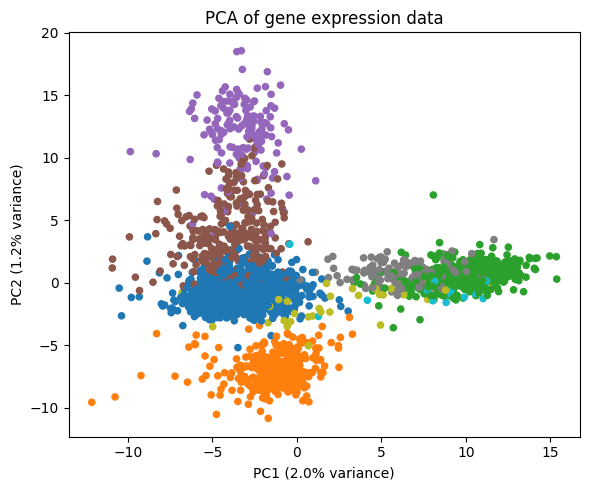

In [43]:
# numeric representation of categorical cell_type feature
labels = pd.factorize(meta_data["cell_type"])[0]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(expression_data)

ev = pca.explained_variance_ratio_

print(f"Explained variance PC1: {ev[0]:.3f}")
print(f"Explained variance PC2: {ev[1]:.3f}")
print(f"Total (PC1 + PC2): {(ev[0]+ev[1]):.3f}")

# Plot PCA projection
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=20)

plt.xlabel(f"PC1 ({ev[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({ev[1]*100:.1f}% variance)")
plt.title("PCA of gene expression data")

plt.tight_layout()
plt.show()

The amount of variance captured by the first two components is very low, so a high number of components must be kept to capture a reasonable amount of variability. With respect to the cell type, the (low) variability captures some distinctive properties

## t-SNE

Much more computationally intensive and less interpretable than PCA (also because of the presence of user-defined hyperparameters)
Its output is mostly used for visualization purposes and not at all as an input for a later statistical model

Usually t-SNE is applied after doing PCA first on the dataset (`init` parameter in `TSNE`) as it is faster and returns better results with respect to the case of random initialization

In [44]:
from sklearn.manifold import TSNE

# t-SNE directly on original data
tsne_raw = TSNE(
    n_components=2,
    perplexity=100,
    init="random",
    learning_rate="auto",
    random_state=42,
    max_iter=1000
)
start = time.time()
X_tsne_raw = tsne_raw.fit_transform(expression_data)
end = time.time()

print(f"t-SNE without PCA runtime: {end - start:.2f} seconds")

# PCA + t-SNE
X_pca50 = PCA(
    n_components=50,
    random_state=42
).fit_transform(expression_data)

tsne_pca = TSNE(
    n_components=2,
    perplexity=100,
    init="pca",
    learning_rate="auto",
    random_state=42,
    max_iter=1000
)

start = time.time()
X_tsne_pca = tsne_pca.fit_transform(X_pca50)
end = time.time()
print(f"t-SNE with PCA runtime: {end - start:.2f} seconds")


# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_tsne_raw[:, 0], X_tsne_raw[:, 1],
                c=labels, cmap="tab10", s=20)
axes[0].set_title("t-SNE on original data")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

axes[1].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1],
                c=labels, cmap="tab10", s=20)
axes[1].set_title("t-SNE after PCA")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

The output of TSNE (with or without PCA first) is not very good when the types are very sparse and well separated

We can explore different values of perplexity. For the algorithm to operate properly, the perplexity really should be smaller than the number of points. Implementations can give unexpected behavior otherwise
In many cases, changing perplexity affects the output of TSNE, but of course there exist some datasets that are not sensible to perplexity

  0%|          | 0/6 [00:00<?, ?it/s]

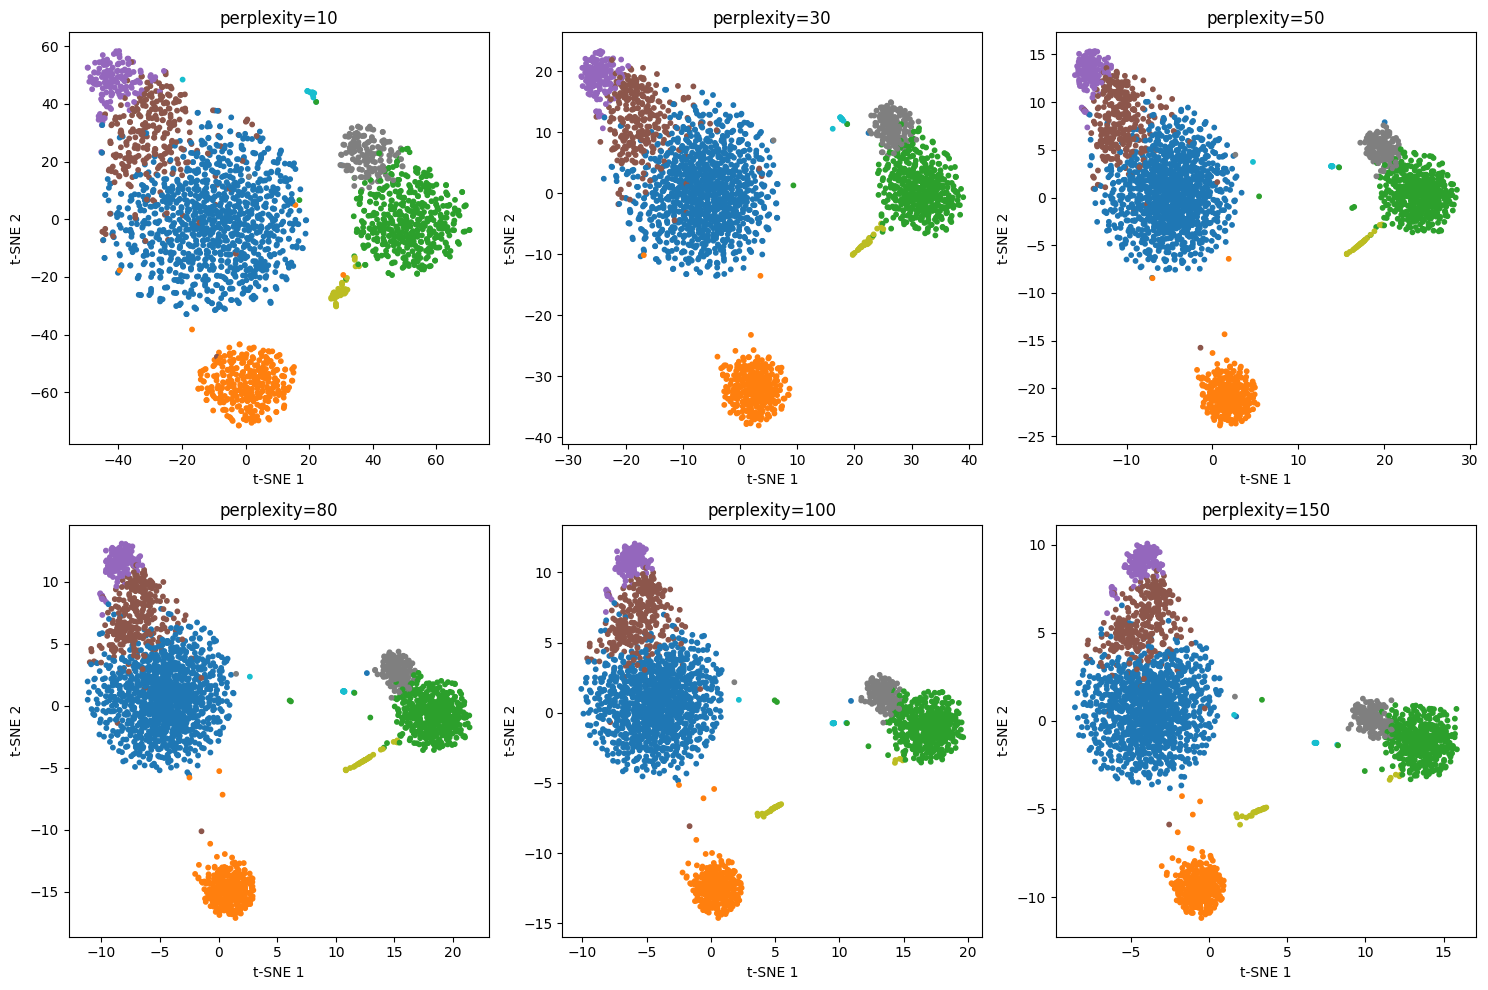

In [ ]:
perplexities = [10, 30, 50, 80, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()  # returns a contiguous flatten array

for ax, p in tqdm(zip(axes, perplexities), total=len(perplexities)):
    Y = TSNE(n_components=2, perplexity=p, init="pca", learning_rate="auto",
             random_state=42, max_iter=1000).fit_transform(X_pca50)

    ax.scatter(Y[:, 0], Y[:, 1], c=labels, cmap="tab10", s=10)
    ax.set_title(f"perplexity={p}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

Perplexity controls the scale of neighborhoods used by t-SNE.
Small values emphasize very local relationships, often producing fragmented embeddings, while large values emphasize global structure but may blur cluster boundaries.

## UMAP

In [ ]:
%pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP without PCA runtime: 32.84 seconds


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP with PCA runtime: 17.15 seconds


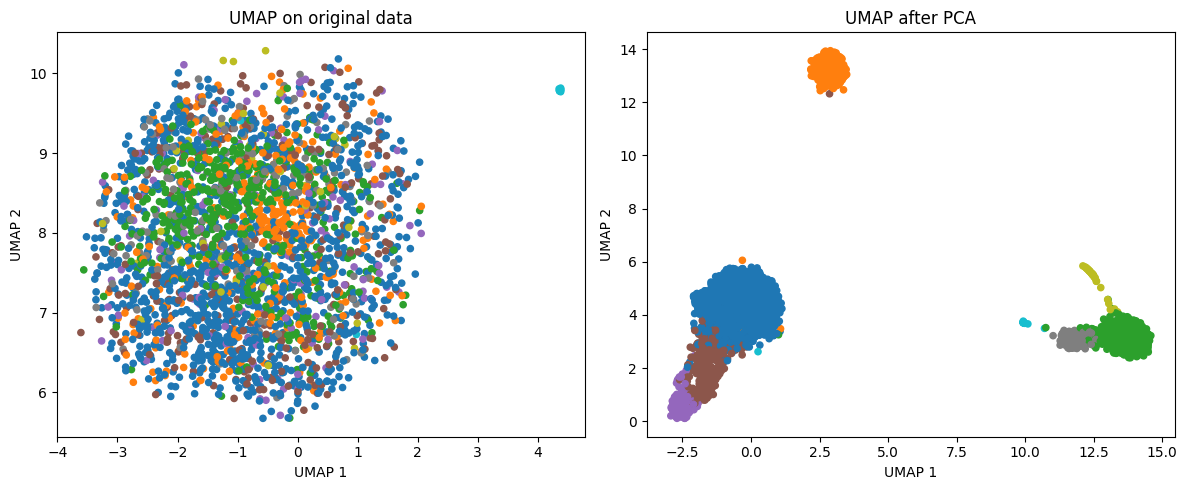

In [ ]:
import umap.umap_ as umap

# UMAP on original data
start = time.time()

X_umap_raw = umap.UMAP(
    n_components=2,
    # n_neighbors must be between 5 and 50, commonly is in [10, 15]
    n_neighbors=15,
    min_dist=0.1,   # min_dist must be between 0.001 and 0.5, commonly is 0.1
    random_state=42
).fit_transform(expression_data)

end = time.time()
print(f"UMAP without PCA runtime: {end - start:.2f} seconds")


# PCA + UMAP
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(expression_data)

start = time.time()

X_umap_pca = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(X_pca50)

end = time.time()
print(f"UMAP with PCA runtime: {end - start:.2f} seconds")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_umap_raw[:, 0], X_umap_raw[:, 1],
                c=labels, cmap="tab10", s=20)
axes[0].set_title("UMAP on original data")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

axes[1].scatter(X_umap_pca[:, 0], X_umap_pca[:, 1],
                c=labels, cmap="tab10", s=20)
axes[1].set_title("UMAP after PCA")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

We can explore different values for min_dist and n_neighbours. Again, the following cell can take several minutes to complete execution

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


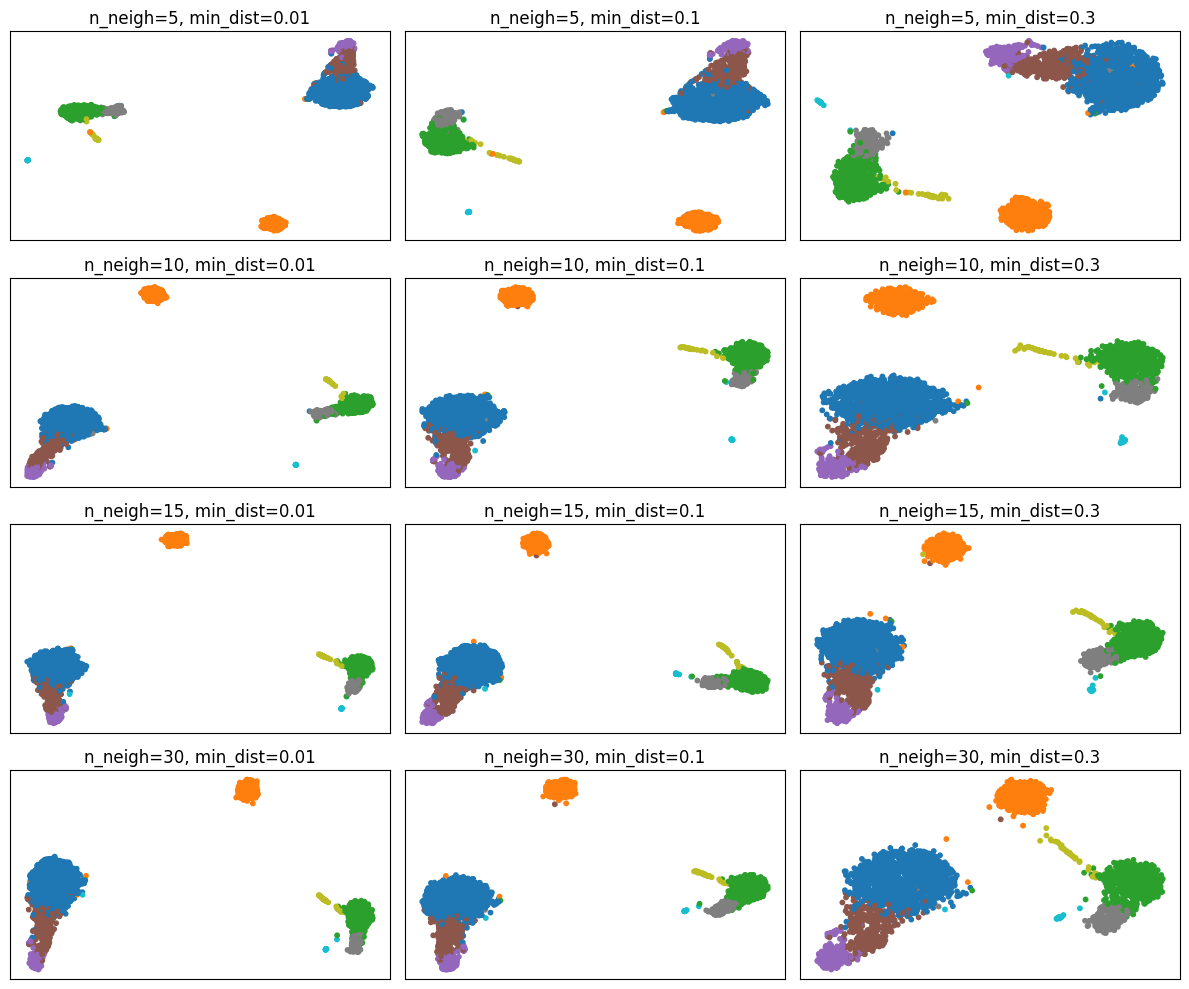

In [ ]:
neighbors_list = [5, 10, 15, 30]
min_dist_list = [0.01, 0.1, 0.3]

fig, axes = plt.subplots(len(neighbors_list), len(min_dist_list),
                         figsize=(12, 10))

for i, n in tqdm(enumerate(neighbors_list), total=len(neighbors_list)):
    for j, d in tqdm(enumerate(min_dist_list), total=len(min_dist_list)):

        embedding = umap.UMAP(
            n_neighbors=n,
            min_dist=d,
            n_components=2,
            random_state=42
        ).fit_transform(X_pca50)

        ax = axes[i, j]
        ax.scatter(embedding[:, 0], embedding[:, 1],
                   c=labels, cmap="tab10", s=10)

        ax.set_title(f"n_neigh={n}, min_dist={d}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

The main parameter of UMAP refers to the number of neighbours.  
UMAP is a bit faster thant t-SNE, but it captures a similar structure for the dataset.  
As t-SNE, UMAP is not high interpretable (as opposite to PCA), but it is generally more stable since its behaviour is not very much affected by its hyperparameters differently from what happens with t-SNE.

# Supplementary

## 3D PCA Visualization

The next cells simulate 3D data, plot the data and a covariance ellipsoid, and then show how the PCA approximates the data by 0D (a point), 1D (a line) and 2D (a plane) representations.

In [ ]:
# Simulate 3D data
mu3 = np.array([0, 2, 3])
sig3 = np.array([[9, 1, 1],
                 [1, 4, 1],
                 [1, 1, 1]])
nobs = 100
X3 = np.random.multivariate_normal(mu3, sig3, nobs)
M3 = X3.mean(axis=0)
S3 = np.cov(X3, rowvar=False)
print('3D sample mean:', M3)
print('3D sample covariance:\n', S3)

3D sample mean: [-0.20132415  1.9213652   2.78113827]
3D sample covariance:
 [[8.48139968 1.48784569 0.87097059]
 [1.48784569 3.50462899 0.79804726]
 [0.87097059 0.79804726 0.91469966]]


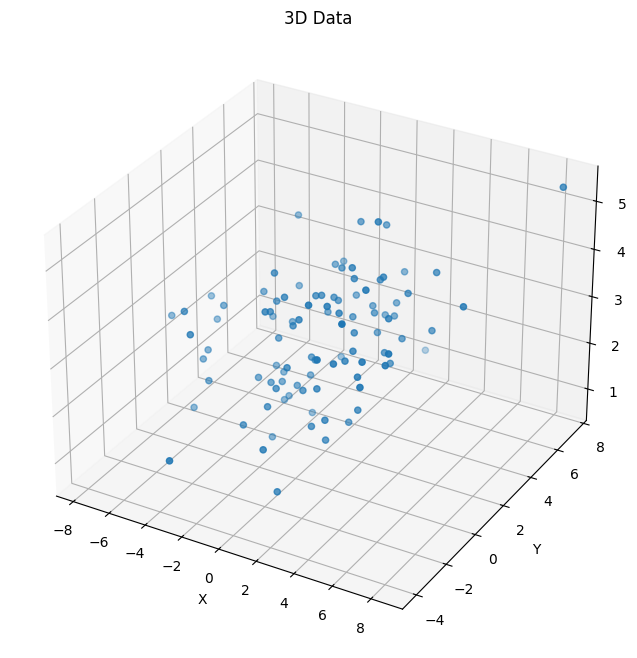

In [ ]:
# 3D plot of data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=20)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D Data')
plt.show()

In [ ]:
pca3 = PCA()
PC_scores = pca3.fit_transform(X3)
print('3D PCA components:\n', pca3.components_)
print('3D PCA explained variance:', pca3.explained_variance_)

3D PCA components:
 [[ 0.95264258  0.27522645  0.12931556]
 [-0.29762469  0.93111372  0.21082405]
 [-0.06238314 -0.23932747  0.96893277]]
3D PCA explained variance: [9.02947988 3.20974336 0.66150509]


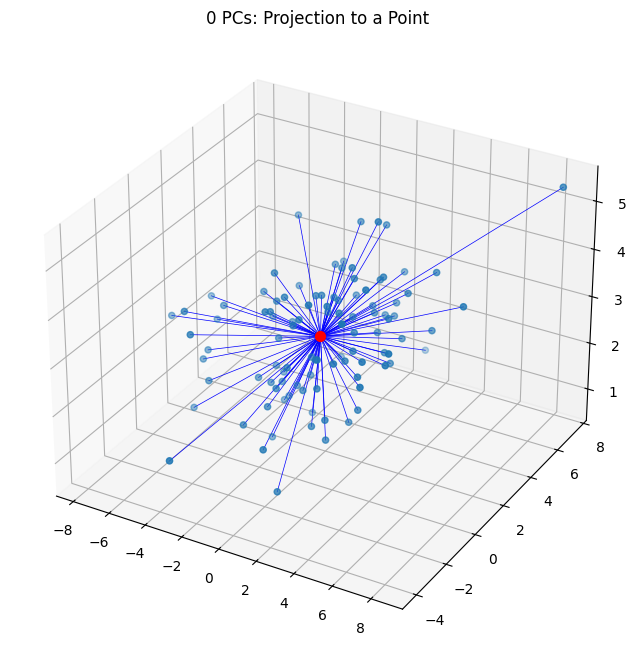

In [ ]:
# 0-dimensional approximation: projection to the mean
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=20)
ax.scatter(M3[0], M3[1], M3[2], color='red', s=50)
for i in range(nobs):
    ax.plot([X3[i, 0], M3[0]], [X3[i, 1], M3[1]], [
            X3[i, 2], M3[2]], color='blue', linewidth=0.5)
ax.set_title('0 PCs: Projection to a Point')
plt.show()

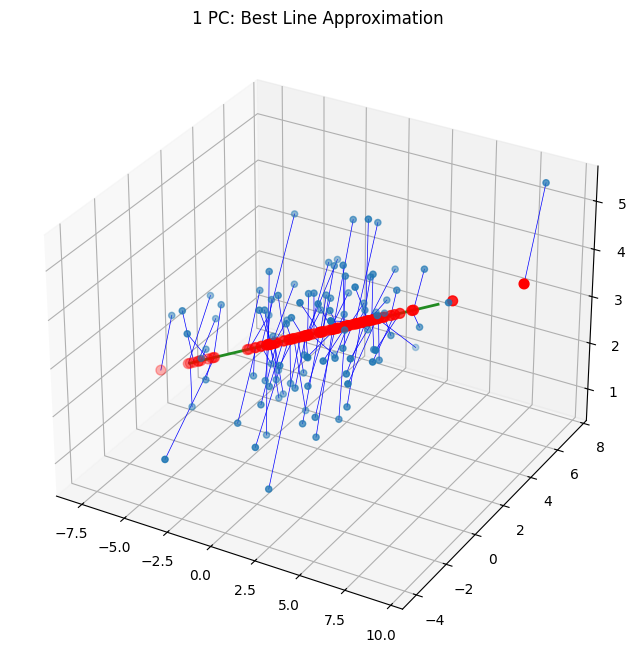

In [ ]:
# 1D approximation: projection on first principal component
explained_std = np.sqrt(pca3.explained_variance_)
PC1 = np.array([M3 + score[0] * pca3.components_[0] for score in PC_scores])
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=20)
ax.scatter(PC1[:, 0], PC1[:, 1], PC1[:, 2], color='red', s=50)
for i in range(nobs):
    ax.plot([X3[i, 0], PC1[i, 0]], [X3[i, 1], PC1[i, 1]], [
            X3[i, 2], PC1[i, 2]], color='blue', linewidth=0.5)
line_PC1 = np.array([M3 + 2*explained_std[0]*pca3.components_[0],
                     M3 - 2*explained_std[0]*pca3.components_[0]])
ax.plot(line_PC1[:, 0], line_PC1[:, 1], line_PC1[:, 2],
        color='forestgreen', linewidth=2)
ax.set_title('1 PC: Best Line Approximation')
plt.show()

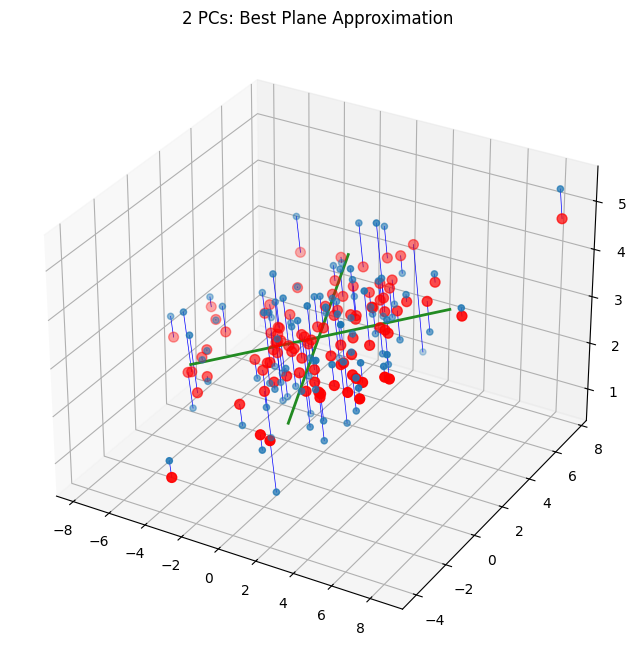

In [ ]:
# 2D approximation: projection on first two principal components
PC12 = np.array([M3 + score[0]*pca3.components_[0] + score[1]
                * pca3.components_[1] for score in PC_scores])
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=20)
ax.scatter(PC12[:, 0], PC12[:, 1], PC12[:, 2], color='red', s=50)
for i in range(nobs):
    ax.plot([X3[i, 0], PC12[i, 0]], [X3[i, 1], PC12[i, 1]], [
            X3[i, 2], PC12[i, 2]], color='blue', linewidth=0.5)
line_PC1 = np.array([M3 + 2*explained_std[0]*pca3.components_[0],
                    M3 - 2*explained_std[0]*pca3.components_[0]])
line_PC2 = np.array([M3 + 2*explained_std[1]*pca3.components_[1],
                    M3 - 2*explained_std[1]*pca3.components_[1]])
ax.plot(line_PC1[:, 0], line_PC1[:, 1], line_PC1[:, 2],
        color='forestgreen', linewidth=2)
ax.plot(line_PC2[:, 0], line_PC2[:, 1], line_PC2[:, 2],
        color='forestgreen', linewidth=2)
ax.set_title('2 PCs: Best Plane Approximation')
plt.show()

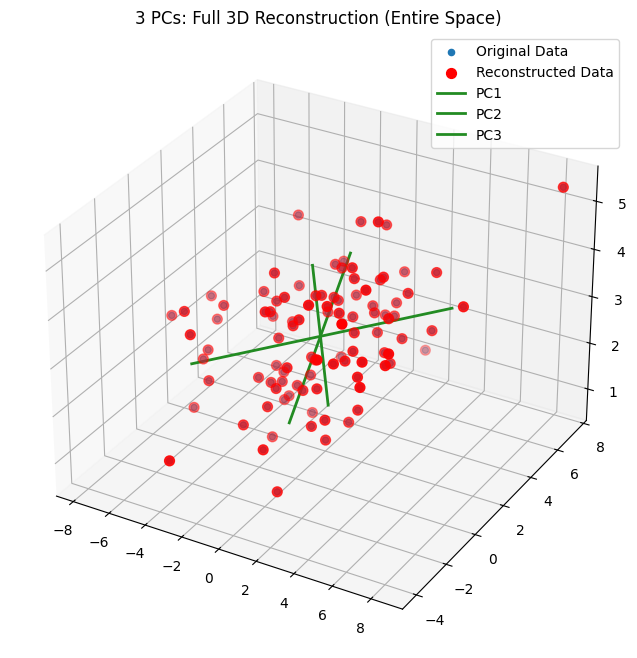

In [ ]:
# Space spanned by all PCs
# I, II and III principal components: the best approximation of dimension 3 (the entire space)

# Reconstruct each observation using all three PCs
# This reconstruction should be almost identical to the original data
PC123 = np.array([
    M3 + score[0]*pca3.components_[0] + score[1] *
    pca3.components_[1] + score[2]*pca3.components_[2]
    for score in PC_scores
])

# Create a 3D figure for the full reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the original 3D data points
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=20, label='Original Data')

# Plot the reconstructed data points (should closely overlay the original points)
ax.scatter(PC123[:, 0], PC123[:, 1], PC123[:, 2],
           color='red', s=50, label='Reconstructed Data')

# Draw blue lines connecting each original point with its reconstruction.
for i in range(nobs):
    ax.plot([X3[i, 0], PC123[i, 0]],
            [X3[i, 1], PC123[i, 1]],
            [X3[i, 2], PC123[i, 2]],
            color='blue', linewidth=0.5)

# For consistency with the 1D and 2D projection codes,
# we plot the principal component directions scaled by 2*standard deviation
line_PC1 = np.array([M3 + 2 * explained_std[0] * pca3.components_[0],
                     M3 - 2 * explained_std[0] * pca3.components_[0]])
line_PC2 = np.array([M3 + 2 * explained_std[1] * pca3.components_[1],
                     M3 - 2 * explained_std[1] * pca3.components_[1]])
line_PC3 = np.array([M3 + 2 * explained_std[2] * pca3.components_[2],
                     M3 - 2 * explained_std[2] * pca3.components_[2]])

# Plot the principal component directions.
ax.plot(line_PC1[:, 0], line_PC1[:, 1], line_PC1[:, 2],
        color='forestgreen', linewidth=2, label='PC1')
ax.plot(line_PC2[:, 0], line_PC2[:, 1], line_PC2[:, 2],
        color='forestgreen', linewidth=2, label='PC2')
ax.plot(line_PC3[:, 0], line_PC3[:, 1], line_PC3[:, 2],
        color='forestgreen', linewidth=2, label='PC3')

ax.set_title("3 PCs: Full 3D Reconstruction (Entire Space)")
ax.legend()

plt.show()

## PCA on the Food Dataset

### Load and visualize dataset

In [ ]:
food = pd.read_csv('Food.txt', sep=' ')
print(food.head())
print('Food dataset shape:', food.shape)

                Meat  Pigs  Eggs  Milk  Fish  Cereals  Pulse  Fruit
Albania         10.1   1.4   0.5   8.9   0.2     42.3    5.5    1.7
Austria          8.9  14.0   4.3  19.9   2.1     28.0    1.3    4.3
Belg.Lux.       13.5   9.3   4.1  17.5   4.5     26.6    2.1    4.0
Bulgaria         7.8   6.0   1.6   8.3   1.2     56.7    3.7    4.2
Czechoslovakia   9.7  11.4   2.8  12.5   2.0     34.3    1.1    4.0
Food dataset shape: (25, 8)


In [ ]:
food.sum(axis=1)

,0
Albania,70.6
Austria,82.8
Belg.Lux.,81.6
Bulgaria,89.5
Czechoslovakia,77.8
Denmark,85.0
East.Germany,69.2
Finland,85.3
France,93.4
Greece,95.5


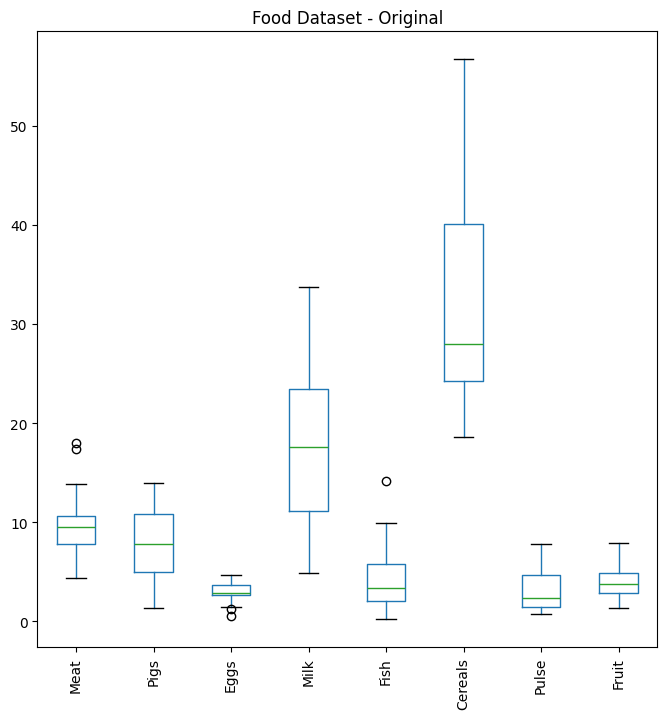

In [ ]:
n_food, p_food = food.shape

food.boxplot(rot=90, grid=False)
plt.title('Food Dataset - Original')
plt.show()

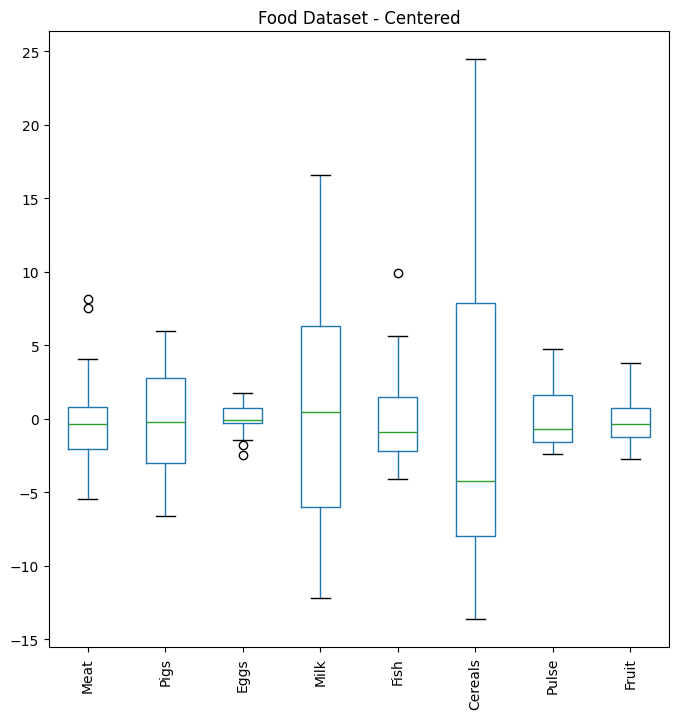

In [ ]:
food_centered = food - food.mean()
plt.figure()
food_centered.boxplot(rot=90, grid=False)
plt.title('Food Dataset - Centered')
plt.show()

### PCA on standardized data

In [ ]:
scaler = StandardScaler()
food_std = scaler.fit_transform(food)
food_std_df = pd.DataFrame(food_std, columns=food.columns)

In [ ]:
pca_food_std = PCA()
food_scores_std = pca_food_std.fit_transform(food_std_df)
print('Standardized Food PCA Explained Variance Ratio\n',
      pca_food_std.explained_variance_ratio_)
loadings_food_std = pca_food_std.components_.T

Standardized Food PCA Explained Variance Ratio
 [0.46323022 0.18218656 0.14032046 0.10846036 0.04107323 0.03496567
 0.01585753 0.01390598]


Standard deviation of the components
 [1.96475235 1.23216125 1.08135894 0.95070306 0.58504438 0.53979676
 0.36351899 0.34041618]
Cumulative Proportion of explained variance
 [0.46323022 0.64541678 0.78573724 0.8941976  0.93527083 0.97023649
 0.98609402 1.        ]


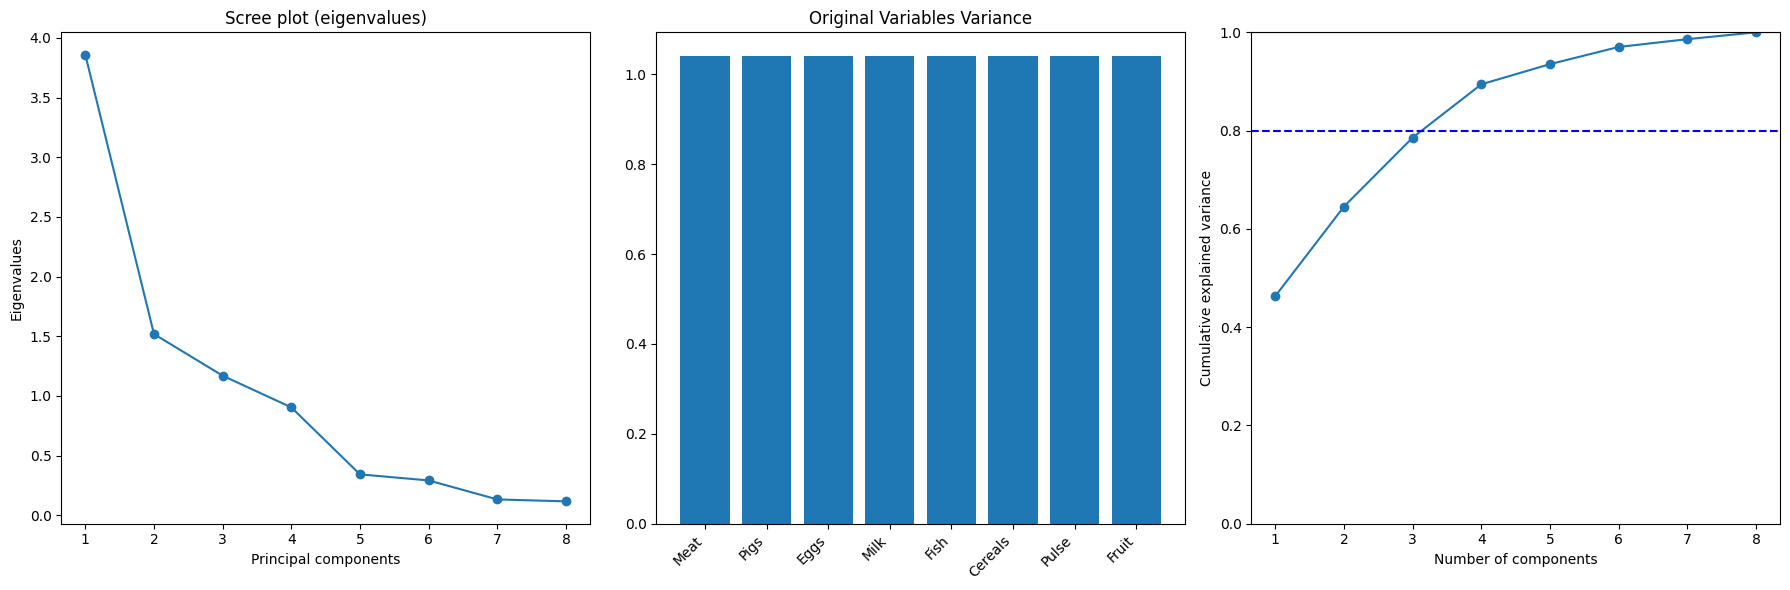

In [ ]:
# Plot PCs variances, original variables variances, scree plot
pc_sd = np.sqrt(pca_food_std.explained_variance_)
print('Standard deviation of the components\n', pc_sd)

cumulative_explained_variance = np.cumsum(
    pca_food_std.explained_variance_ratio_)
print('Cumulative Proportion of explained variance\n',
      cumulative_explained_variance)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].plot(np.arange(1, p_food+1),
            pca_food_std.explained_variance_, marker='o')
axs[0].set_title('Scree plot (eigenvalues)')
axs[0].set_xlabel('Principal components')
axs[0].set_ylabel('Eigenvalues')

orig_variances = food_std_df.var(ddof=1)
axs[1].bar(food.columns, orig_variances)
axs[1].tick_params(axis='x', rotation=45)
plt.setp(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[1].set_title('Original Variables Variance')

cum_explained = np.cumsum(pca_food_std.explained_variance_ratio_)
axs[2].plot(np.arange(1, p_food+1), cum_explained, marker='o')
axs[2].axhline(1, color='blue')
axs[2].axhline(0.8, color='blue', linestyle='--')
axs[2].set_xlabel('Number of components')
axs[2].set_ylabel('Cumulative explained variance')
axs[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

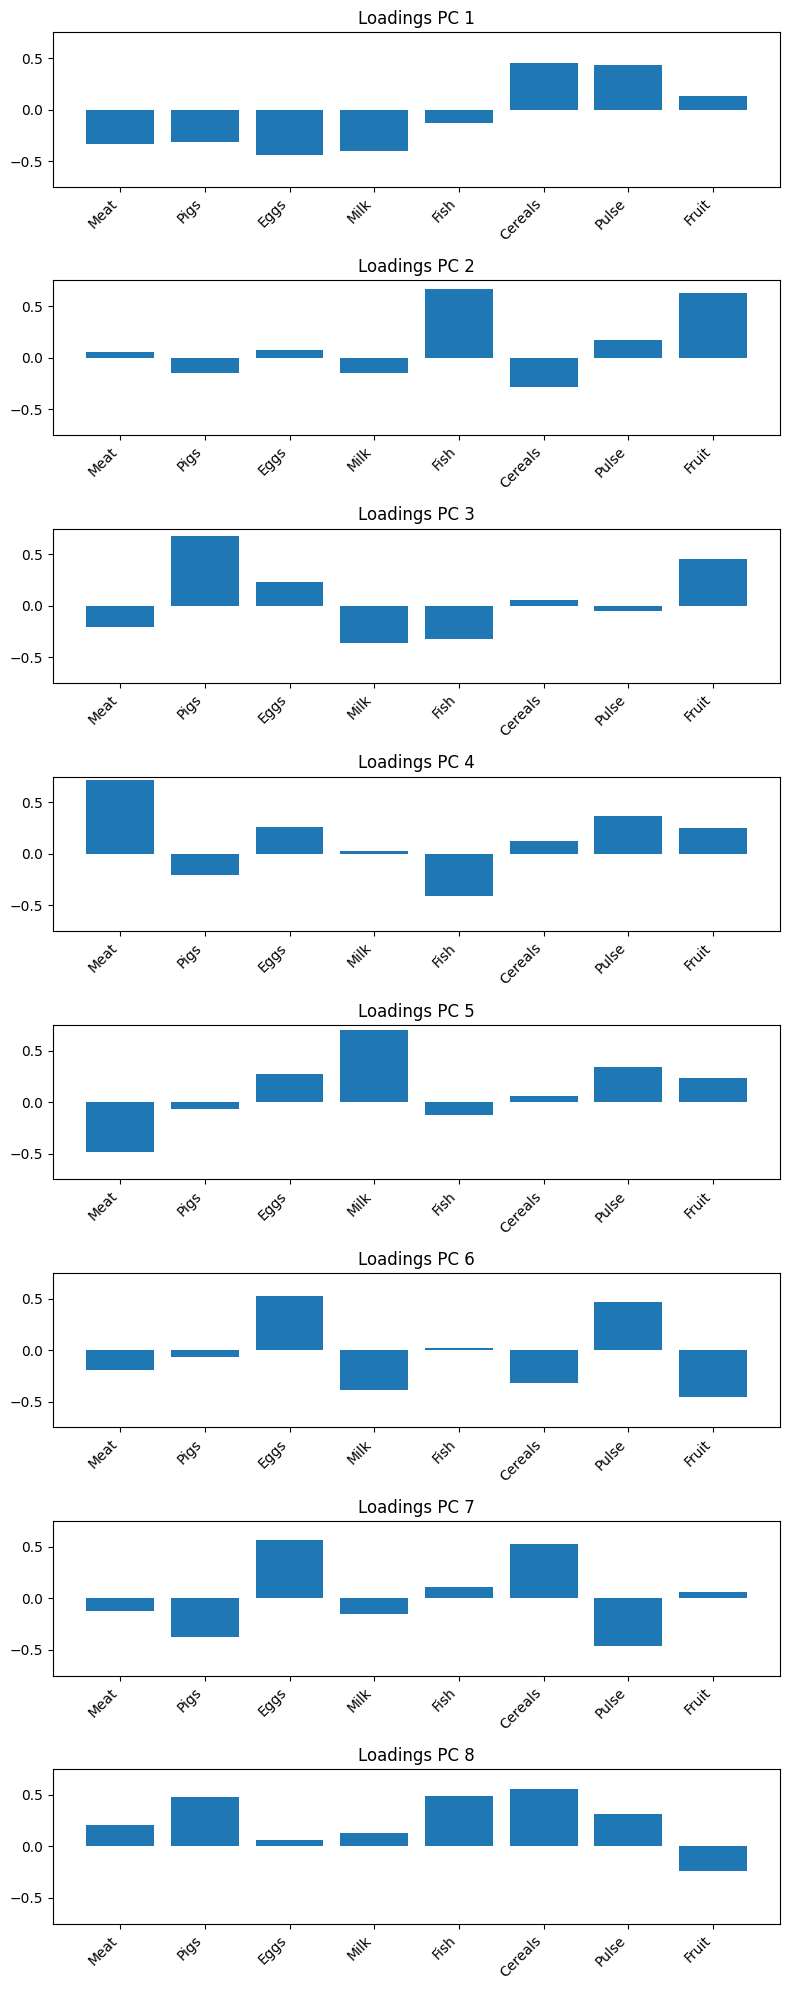

In [ ]:
load_food_std = pca_food_std.components_.T
load_food_std

fig, axs = plt.subplots(p_food, 1, figsize=(8, 20))
for i in range(p_food):
    axs[i].bar(food_std_df.columns, load_food_std[:, i])
    axs[i].set_ylim([-0.75, 0.75])
    axs[i].set_title(f'Loadings PC {i+1}')
    axs[i].tick_params(axis='x', rotation=45)
    plt.setp(axs[i].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's have a look at how well we can reconstruct the original data with an increasing number of components

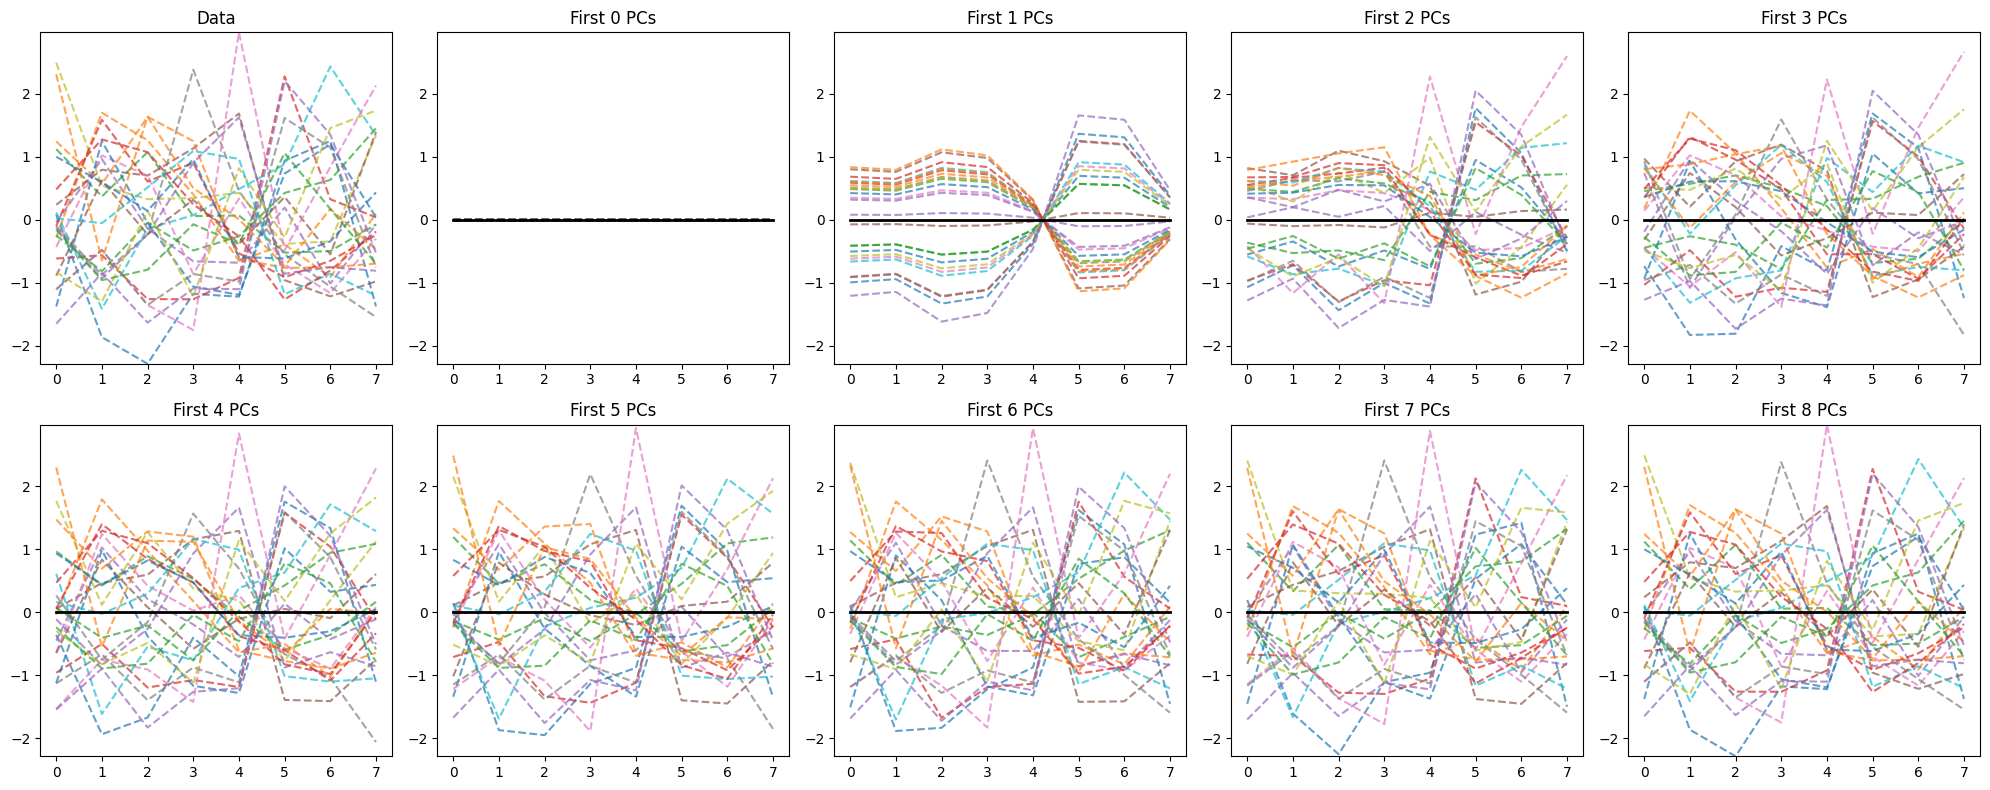

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_obs, n_vars = food_std_df.shape
# x-axis: one value for each variable (or use food_sd.columns if preferred)
x = np.arange(n_vars)

# Create a figure with 2 rows and 5 columns (10 subplots total)
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()  # Flatten for easy iteration

# --- Plot the Original Data ---
# Each observation (each row of food_sd) is plotted as a line.
for i in range(n_obs):
    axs[0].plot(x, food_std_df.iloc[i, :], '--', alpha=0.7)
axs[0].set_title("Data")
axs[0].set_ylim(food_std_df.values.min(), food_std_df.values.max())

# --- Plot the "First 0 PCs" Approximation ---
# Compute the mean vector (i.e. the column means) of food_sd.
meanF = food_std_df.mean(axis=0).values

# Create an initial projection matrix that is just the mean for every observation.
projection = np.tile(meanF, (n_obs, 1))
for i in range(n_obs):
    axs[1].plot(x, projection[i, :], '--', color='black', alpha=0.7)
# Overlay the overall mean as a thick black line.
axs[1].plot(x, meanF, 'k-', linewidth=2)
axs[1].set_title("First 0 PCs")
axs[1].set_ylim(food_std_df.values.min(), food_std_df.values.max())

# --- Iteratively Add the Contributions of the First k PCs ---
# For each component from 1 to 8 (or fewer if there are not 8 PCs),
# update the projection by adding the outer product of the PC scores and its loading.
scores_food = pca_food_std.transform(food_std_df)
scores_food_df = pd.DataFrame(scores_food, columns=food.columns)
num_components = min(8, scores_food_df.shape[1])
for comp in range(num_components):
    # Update: for the comp-th PC, add (score for that PC) * (loading vector for that PC)
    # This yields an (n_obs x n_vars) matrix.
    projection = projection + \
        np.outer(scores_food_df.iloc[:, comp], loadings_food_std[:, comp])

    # Plot the updated projection in subplot comp+2 (since index 0 is original data, index 1 is 0 PCs).
    ax = axs[comp + 2]
    # Plot one line per observation (i.e. each row of projection)
    for i in range(n_obs):
        ax.plot(x, projection[i, :], '--', alpha=0.7)
    # Optionally overlay the mean for reference.
    ax.plot(x, meanF, 'k-', linewidth=2)
    ax.set_title(f"First {comp+1} PCs")
    ax.set_ylim(food_std_df.values.min(), food_std_df.values.max())

plt.tight_layout()
plt.show()

In the first plot each line corresponds to an observation of the original dataset  
In the second plot there are no principal components: each observation is represented by the mean, which is zero for all since they were standardized  
From the third plot on we progressively add more principal components

## t-SNE and UMAP on digits dataset

Let's load a default dataset of 8x8 images depicting digits

In [45]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

In [46]:
X.shape

(1797, 64)

##################################################
2D PCA
##################################################
 - Runtime: 0.01 sec.
 - Explained Variance PC1 (%): 14.890593584063843
 - Explained Variance PC2 (%): 13.618771239635441
 - Total Explained Variance (%): 28.509364823699286
##################################################
t-SNE
##################################################
 - Runtime: 16.25 sec.
##################################################
UMAP
##################################################


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 - Runtime: 7.62 sec.


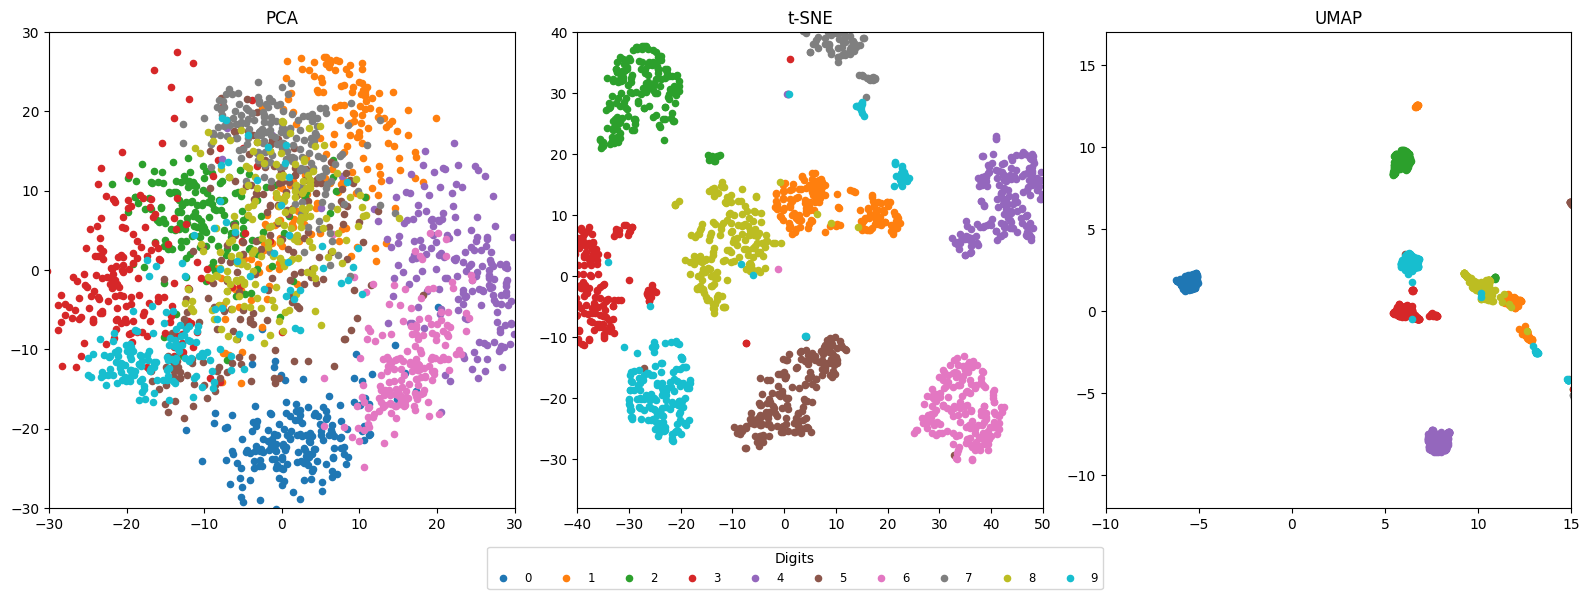

In [ ]:
print("##################################################")
print("2D PCA")
print("##################################################")
start = time.time()
pca_digits_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_digits_2d.fit_transform(X)
end = time.time()
ev_pc1 = pca_digits_2d.explained_variance_ratio_[0] * 100
ev_pc2 = pca_digits_2d.explained_variance_ratio_[1] * 100
print(f" - Runtime: {end - start:.2f} sec.")
print(f" - Explained Variance PC1 (%): {ev_pc1}")
print(f" - Explained Variance PC2 (%): {ev_pc2}")
print(f" - Total Explained Variance (%): {ev_pc1 + ev_pc2}")

# PCA for UMAP
pca_digits = PCA(n_components=50, random_state=42)
X_pca = pca_digits.fit_transform(X)

print("##################################################")
print("t-SNE")
print("##################################################")

tsne_pca = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
    max_iter=1000
)
start = time.time()
X_tsne_pca = tsne_pca.fit_transform(X)
end = time.time()
print(f" - Runtime: {end - start:.2f} sec.")

print("##################################################")
print("UMAP")
print("##################################################")

embedding = umap.UMAP(
    n_neighbors=30,
    min_dist=0.01,
    random_state=42
)
start = time.time()
X_umap = embedding.fit_transform(X_pca)
end = time.time()
print(f" - Runtime: {end - start:.2f} sec.")

fig, axs = plt.subplots(1, 3, figsize=(16, 6))
axs = axs.flatten()

cmap = plt.get_cmap("tab10")
for digit in np.unique(y):
    mask = y == digit
    axs[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                   color=cmap(digit), s=20, label=str(digit))
    axs[1].scatter(X_tsne_pca[mask, 0], X_tsne_pca[mask, 1],
                   color=cmap(digit), s=20, label=str(digit))
    axs[2].scatter(X_umap[mask, 0], X_umap[mask, 1],
                   color=cmap(digit), s=20, label=str(digit))

axs[0].set_title("PCA")
axs[0].set_xlim([-30, 30])
axs[0].set_ylim([-30, 30])

axs[1].set_title("t-SNE")
axs[1].set_xlim([-40, 50])
axs[1].set_ylim([-38, 40])

axs[2].set_title("UMAP")
axs[2].set_xlim([-10, 15])
axs[2].set_ylim([-12, 17])

handles, labels = axs[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=len(
    np.unique(y)), bbox_to_anchor=(0.5, 0.0), fontsize="small", title="Digits")

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

# Feedback

Please leave a feedback on this lab through [this form](https://forms.office.com/e/HSgSw9Uvjk) (estimated 2 minutes)